In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
# INPUT_DIR = "/n/groups/kirschner/Will/MetabolicObesity/sc"
INPUT_DIR = "inputs"

samples = {
    "BRI-1456": {
        "disease": "Healthy",
        "tissue": "SQ",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1457": {
        "disease": "Unhealthy",
        "tissue": "SQ",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1458": {
        "disease": "Healthy",
        "tissue": "Omentum",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
    "BRI-1459": {
        "disease": "Unhealthy",
        "tissue": "Omentum",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
}

In [4]:
clusterings = ["merge_samples",]  #["separate_samples", "intercept_samples", ]

for sample_name, sample in samples.items():
    
    sample["input_folder"] = os.path.join(INPUT_DIR, sample_name, "filtered_feature_bc_matrix")

    sample["cluster_fp"] = {
        clustering: os.path.join(INPUT_DIR, "demultiplex", clustering, sample_name, "clusters.tsv")  for clustering in clusterings
    }
om_annotated_fp = os.path.join(INPUT_DIR, "OM_merge.rds")
om_lympho_annotated_fp = os.path.join(INPUT_DIR, "OM_Lympho.rds")
om_myeloid_annotated_fp = os.path.join(INPUT_DIR, "OM_Myeloid.rds")

sq_annotated_fp = os.path.join(INPUT_DIR, "SQ_merge.rds")
sq_lympho_annotated_fp = os.path.join(INPUT_DIR, "SQ_Lympho.rds")
sq_myeloid_annotated_fp = os.path.join(INPUT_DIR, "SQ_Myeloid.rds")

# Cell counts check

In [5]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
Trying to import in ABI mode.


%%R
 <!-- BiocManager::install("edgeR") -->
BiocManager::install("Seurat")

In [6]:
%%R -i sq_annotated_fp,om_annotated_fp,om_lympho_annotated_fp,om_myeloid_annotated_fp,sq_lympho_annotated_fp,sq_myeloid_annotated_fp

library(Seurat)

# Read the Seurat object from the RDS file
seurat_object_sq <- readRDS(sq_annotated_fp)
seurat_object_om <- readRDS(om_annotated_fp)


# Read the Seurat object from the RDS file
seurat_object_sq_myel <- readRDS(sq_myeloid_annotated_fp)
seurat_object_om_myel <- readRDS(om_myeloid_annotated_fp)


# Read the Seurat object from the RDS file
seurat_object_sq_lymph <- readRDS(sq_lympho_annotated_fp)
seurat_object_om_lymph <- readRDS(om_lympho_annotated_fp)

# You can now work with the loaded Seurat object
# For example, to view the object summary:
# print(seurat_object)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Loading required package: SeuratObject
Loading required package: sp

Attaching package: ‘SeuratObject’

The following objects are masked from ‘package:base’:

    intersect, t

In addition: Warning message:
package ‘sp’ was built under R version 4.5.2 


In [7]:
%%R -o metadata_om,metadata_sq,metadata_om_myel,metadata_sq_myel,metadata_om_lymph,metadata_sq_lymph

seurat_object_om[["cell_type"]] <- Idents(seurat_object_om)
metadata_om <- seurat_object_om[[]]

seurat_object_sq[["cell_type"]] <- Idents(seurat_object_sq)
metadata_sq <- seurat_object_sq[[]]

seurat_object_sq_myel[["cell_type"]] <- Idents(seurat_object_sq_myel)
metadata_sq_myel <- seurat_object_sq_myel[[]]
seurat_object_om_myel[["cell_type"]] <- Idents(seurat_object_om_myel)
metadata_om_myel <- seurat_object_om_myel[[]]

seurat_object_sq_lymph[["cell_type"]] <- Idents(seurat_object_sq_lymph)
metadata_sq_lymph <- seurat_object_sq_lymph[[]]
seurat_object_om_lymph[["cell_type"]] <- Idents(seurat_object_om_lymph)
metadata_om_lymph <- seurat_object_om_lymph[[]]


In [9]:
%%R -o umap_om,umap_sq

umap_om <- Embeddings(seurat_object_om, reduction = "umap")
umap_sq <- Embeddings(seurat_object_sq, reduction = "umap")

In [10]:
metadata = {
    "Omentum": {"cell_type": metadata_om, "cell_subtype": [metadata_om_lymph, metadata_om_myel]},
    "SQ": {"cell_type": metadata_sq, "cell_subtype": [metadata_sq_lymph, metadata_sq_myel]}
}

In [11]:
umap = {
    "Omentum": umap_om,
    "SQ": umap_sq
}

In [12]:
for tissue, t_umap in umap.items():
    t_met = metadata[tissue]["cell_type"]
    t_met[["UMAP_1", "UMAP_2"]] = t_umap

In [13]:
for sample_name, sample in samples.items():
    
    adata = sc.read_10x_mtx(sample["input_folder"])
    sample["adata"] = adata

    for cluster_type, clusters_fp in sample["cluster_fp"].items():
        clusters = pd.read_csv(clusters_fp, sep="\t")
    
        cols = list(clusters.columns)
        cols.remove("barcode")
        
        # cols_cluster_type = [f"{col}_{cluster_type}" for col in cols]
        
        adata.obs[cols] = clusters.set_index("barcode").loc[adata.obs_names, cols]

    adata.obs[["sample_name", "disease", "tissue"]] = sample_name, sample["disease"], sample["tissue"]
    # adata.obs["sample"] = "SQ_MHO"

    adata.obs["barcode_r"] = adata.obs_names.to_series() + sample["barcode_r"]

    tissue_metadata = metadata[sample["tissue"]]
    adata.obs = adata.obs.join(tissue_metadata["cell_type"], on="barcode_r", validate="one_to_one")
    
    adata.obs["cell_subtype"] = adata.obs["cell_type"].astype(str)
    
    for subtype_metadata in tissue_metadata["cell_subtype"]:
        idx = adata.obs.barcode_r.isin(subtype_metadata.index)
        adata.obs.loc[idx, "cell_subtype"] = subtype_metadata.loc[adata.obs.loc[idx, "barcode_r"], "cell_type"].values

    cell_subtypes = adata.obs.value_counts(["cell_type", "cell_subtype"]).sort_index().reset_index()["cell_subtype"].unique()
    adata.obs["cell_subtype"] = pd.Categorical(adata.obs["cell_subtype"], ordered=True, categories=cell_subtypes)
    adata.obsm["X_umap"] = adata.obs[["UMAP_1", "UMAP_2"]].values

### Clusterings comparison

In [43]:
adata.obs

,status_separate_samples,assignment_separate_samples,singlet_posterior_separate_samples,doublet_posterior_separate_samples,log_prob_singleton_separate_samples,log_prob_doublet_separate_samples,cluster0_separate_samples,cluster1_separate_samples,cluster2_separate_samples,cluster3_separate_samples,...,orig.ident,nCount_RNA,nFeature_RNA,Sample,percent.mt,RNA_snn_res.0.5,seurat_clusters,cell_type,UMAP_1,UMAP_2
AAACCCAAGCAACTTC-1,singlet,1,1.0,0.000000e+00,-258.420283,-341.364402,-612.899356,-258.420283,-654.504050,-605.807650,...,SeuratProject,5943.0,1423.0,OM_MUO,4.307589,0,0,T cells,4.988994,1.580271
AAACCCAAGCATGCGA-1,singlet,2,1.0,0.000000e+00,-132.538451,-176.156484,-401.994243,-356.696839,-132.538451,-346.379115,...,SeuratProject,3983.0,1351.0,OM_MUO,6.050716,0,0,T cells,4.695494,3.551962
AAACCCAAGCGGATCA-1,singlet,3,1.0,3.931000e-13,-112.140774,-140.705375,-231.657585,-246.580854,-201.934254,-112.140774,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCCACAAATCCCA-1,singlet,3,1.0,0.000000e+00,-294.423370,-403.955335,-816.214062,-875.383991,-820.202599,-294.423370,...,SeuratProject,10757.0,2466.0,OM_MUO,13.358743,3,3,MSLN+,-7.136287,8.611437
AAACCCACAAATGAAC-1,doublet,2/0,1.0,1.000000e+00,-1227.624774,-943.180994,-1415.580949,-1998.843064,-1227.624774,-1871.820871,...,SeuratProject,18410.0,4145.0,OM_MUO,5.507876,4,4,PI16+,-6.814624,-1.885607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTGACTGAG-1,singlet,4,1.0,0.000000e+00,-233.975713,-298.815550,-580.496573,-593.356918,-528.987008,-553.179207,...,SeuratProject,5912.0,1955.0,OM_MUO,8.440460,1,1,PDGFRA+,-3.344473,-5.326329
TTTGTTGGTTAGGACG-1,singlet,3,1.0,0.000000e+00,-450.787019,-627.213238,-1439.352400,-1251.505092,-1462.905071,-450.787019,...,SeuratProject,15208.0,3056.0,OM_MUO,5.273540,4,4,PI16+,-7.452656,-3.795428
TTTGTTGTCGAGTTGT-1,singlet,3,1.0,0.000000e+00,-264.764600,-364.336700,-867.482113,-729.192160,-788.179122,-264.764600,...,SeuratProject,9088.0,2684.0,OM_MUO,7.823504,4,4,PI16+,-7.580495,-1.706323
TTTGTTGTCTCACTCG-1,singlet,3,1.0,0.000000e+00,-250.203561,-322.419167,-624.842322,-588.651936,-574.280000,-250.203561,...,SeuratProject,5415.0,1403.0,OM_MUO,12.336103,13,13,B cells,11.415726,-3.347104


#### separate_samples vs merge_samples

In [88]:
clusterings_vs = ["separate_samples", "merge_samples"]

In [89]:
assignments = {}

for sample in samples:
    
    adata = sample["adata"]
    sample_name = sample["sample_name"]
    
    vs_cols = []
    
    for clustering in clusterings_vs:
        
        vs_col = f"assignment_{clustering}_"
        vs_cols.append(vs_col)
        
        adata.obs[vs_col] = adata.obs[f"assignment_{clustering}"]
        adata.obs.loc[adata.obs[f"status_{clustering}"].isin(["doublet", "unassigned"]), vs_col] = "doublet/unassigned"
    
    assignments[sample_name] = adata.obs.value_counts(vs_cols)

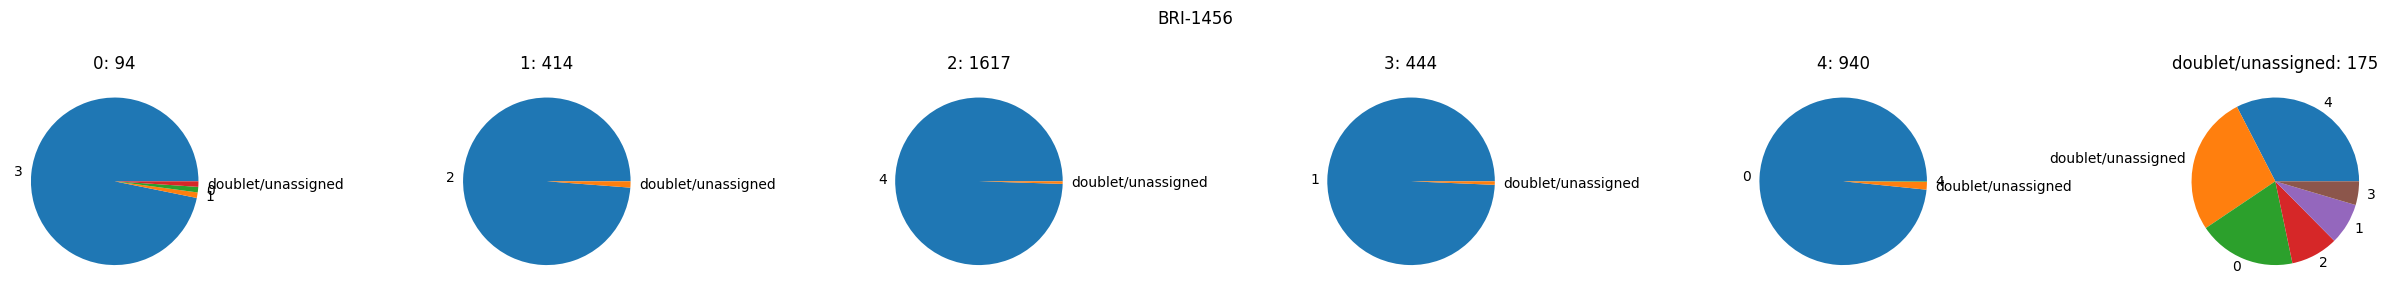

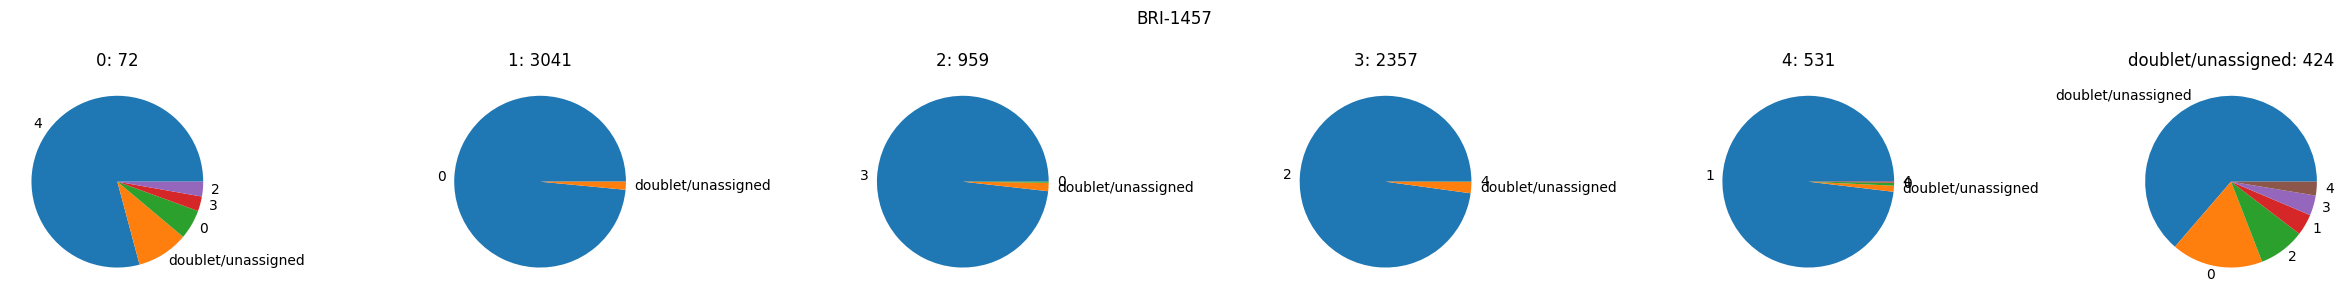

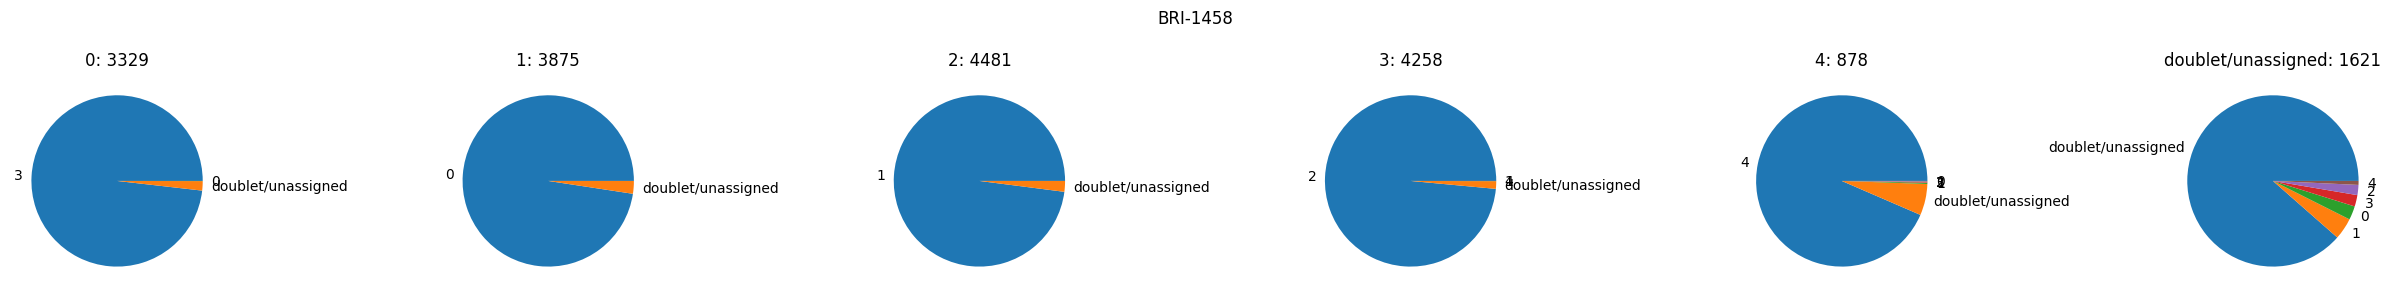

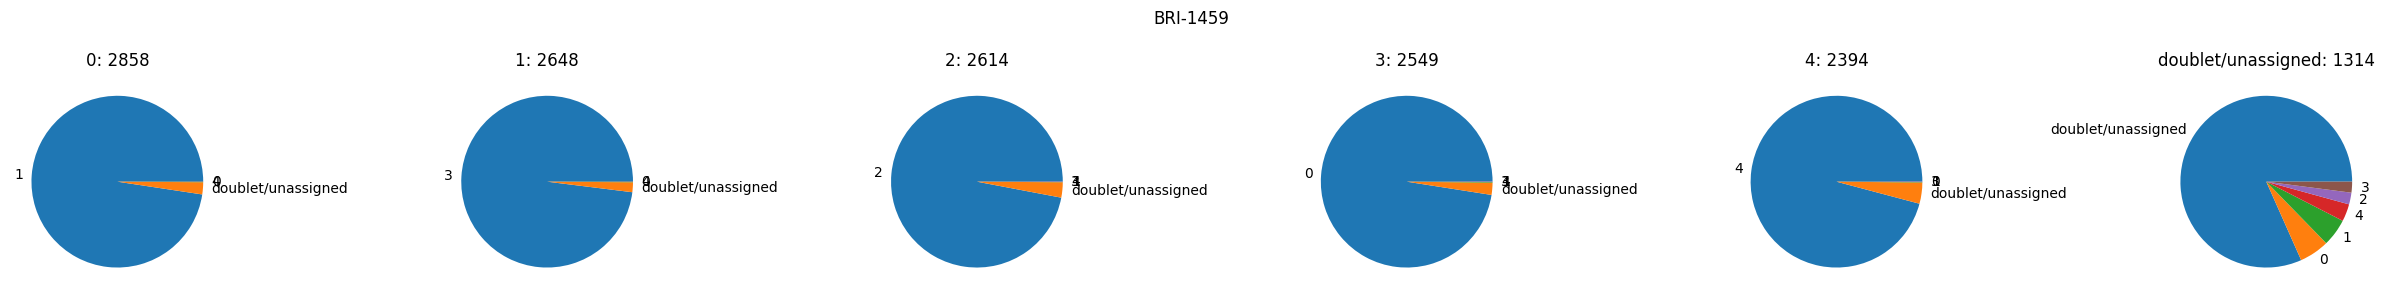

In [90]:
for sample, assignment in assignments.items():

    assignment_ = assignment.reset_index().groupby("assignment_separate_samples_")
    
    fig, axs = plt.subplots(1, len(assignment_.groups), figsize=(24, 3))
    
    i = 0
    
    for participant, participant_assignemtns in assignment_:
        
        labels = participant_assignemtns["assignment_merge_samples_"]
        sizes = participant_assignemtns["count"]
        axs[i].pie(sizes, labels=labels)
        axs[i].set_title(f"{participant}: {sum(participant_assignemtns['count'])}")
        i += 1

    fig.suptitle(sample)
    fig.tight_layout()
    plt.show()

#### separate_samples vs intercept_samples

In [77]:
clusterings_vs = ["separate_samples", "intercept_samples"]

In [84]:
assignments = {}

for sample in samples:
    
    adata = sample["adata"]
    sample_name = sample["sample_name"]
    
    vs_cols = []
    
    for clustering in clusterings_vs:
        
        vs_col = f"assignment_{clustering}_"
        vs_cols.append(vs_col)
        
        adata.obs[vs_col] = adata.obs[f"assignment_{clustering}"]
        adata.obs.loc[adata.obs[f"status_{clustering}"].isin(["doublet", "unassigned"]), vs_col] = "doublet/unassigned"
    
    assignments[sample_name] = adata.obs.value_counts(vs_cols)

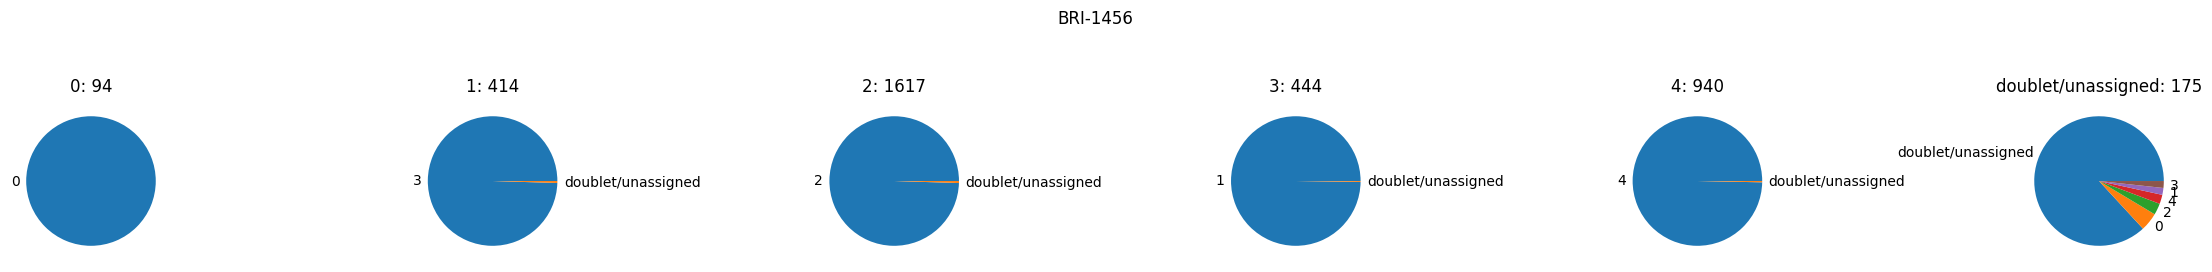

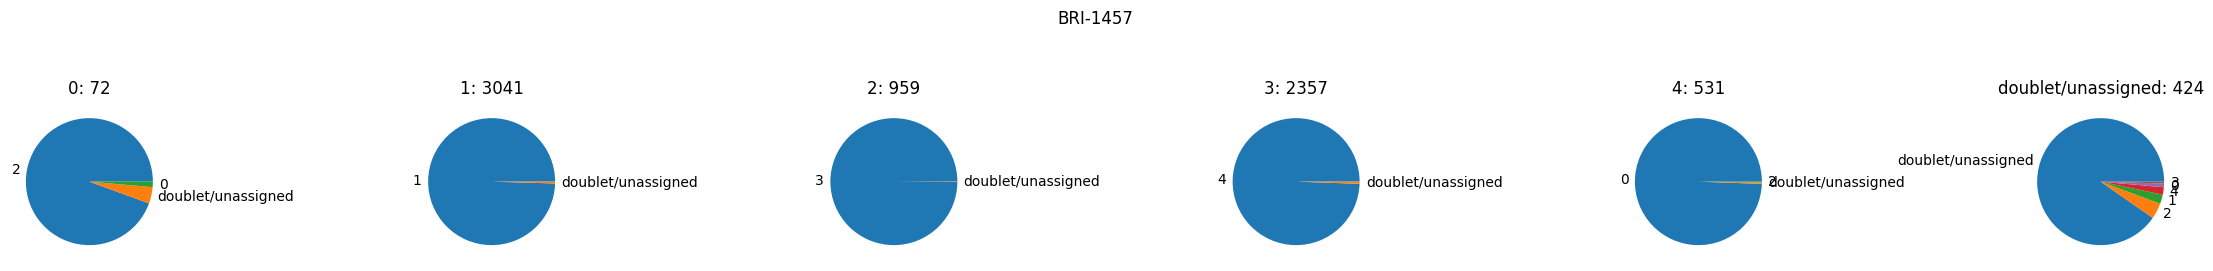

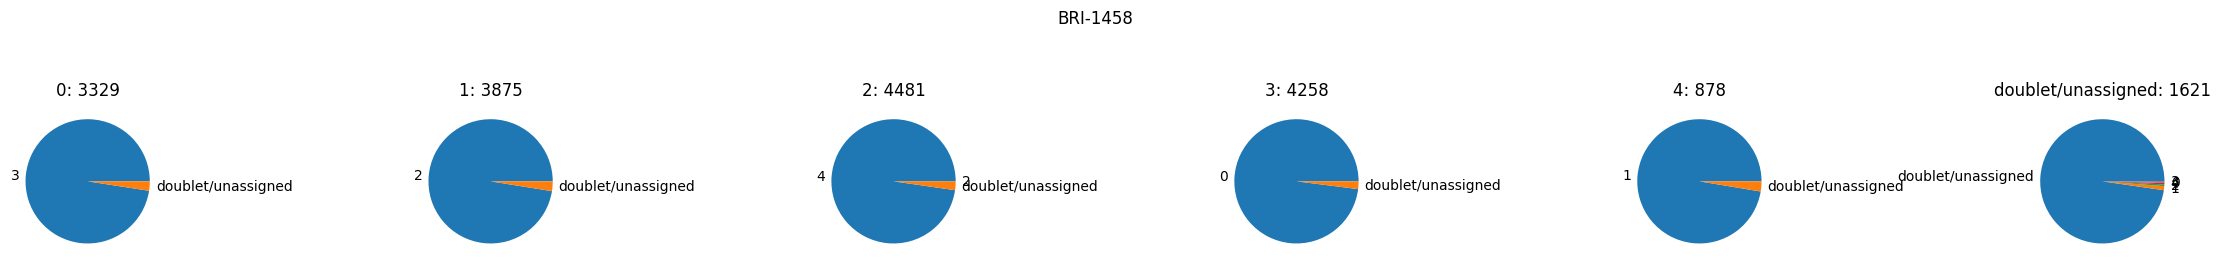

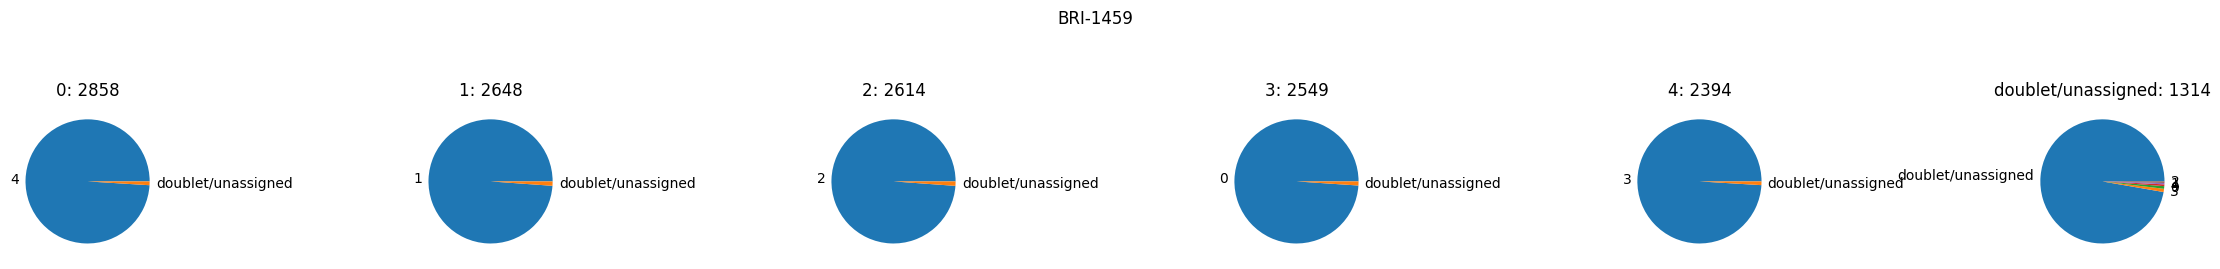

In [87]:
for sample, assignment in assignments.items():

    assignment_ = assignment.reset_index().groupby("assignment_separate_samples_")
    
    fig, axs = plt.subplots(1, len(assignment_.groups), figsize=(22, 3))
    
    i = 0
    
    for participant, participant_assignemtns in assignment_:
        
        labels = participant_assignemtns["assignment_intercept_samples_"]
        sizes = participant_assignemtns["count"]
        axs[i].pie(sizes, labels=labels)
        axs[i].set_title(f"{participant}: {sum(participant_assignemtns['count'])}")
        i += 1

    fig.suptitle(sample)
    fig.tight_layout()
    plt.show()

## UMAPs

In [16]:
singlets = [str(i) for i in range(5)]
new_assign_col = "assignment_"

for sample_name, sample in samples.items():
    adata = sample["adata"]
    
    
    adata.obs[new_assign_col] = adata.obs["assignment"]
    adata.obs.loc[adata.obs.status == "doublet", new_assign_col] = "doublet"
    adata.obs.loc[adata.obs.status == "unassigned", new_assign_col] = "unassigned"
    adata.obs["sex"] = [sample["sex"][assignment] if assignment in sample["sex"] else None for assignment in adata.obs.assignment]

    adata_sing = adata[adata.obs.status == "singlet",:].copy()
    adata_sing.obs["participant"] = sample["disease"] + "_" + adata_sing.obs["assignment"].astype(str)
    adata_sing.obs.assignment = pd.Categorical(adata_sing.obs.assignment, categories=singlets)
    adata_sing.obs["sex"] = [sample["sex"][assignment] for assignment in adata_sing.obs.assignment]
    
    sample["adata_sing"] = adata_sing


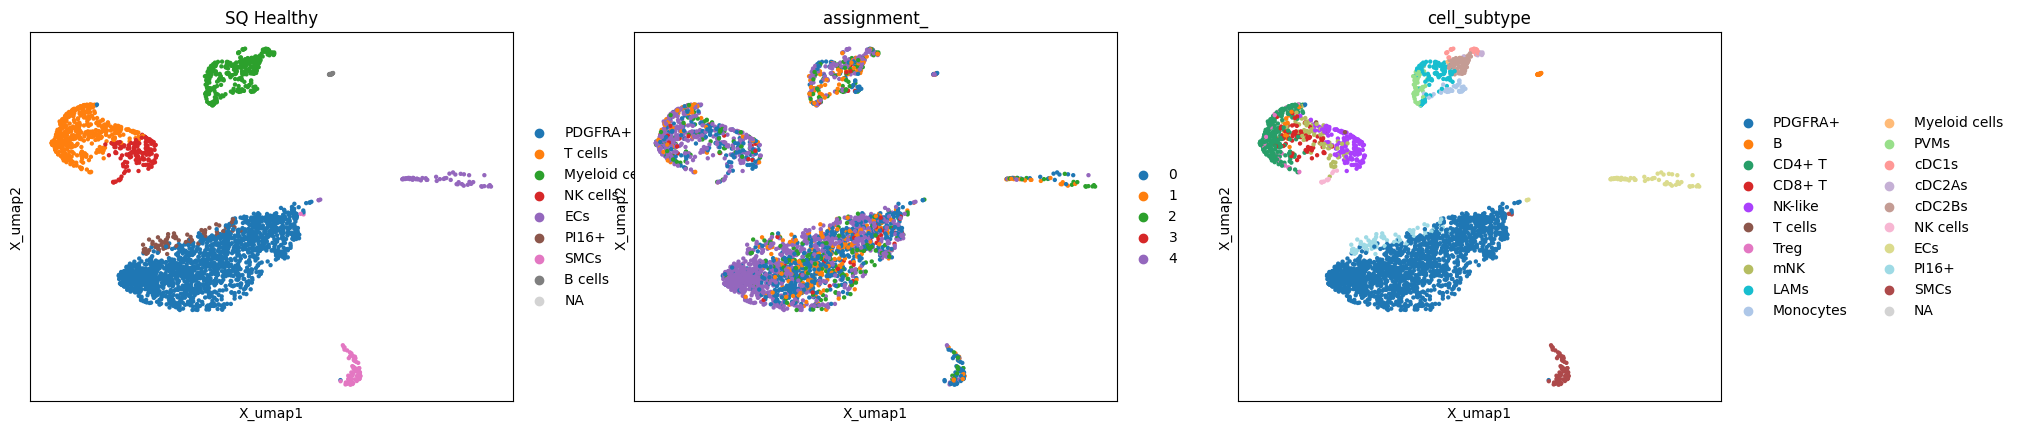

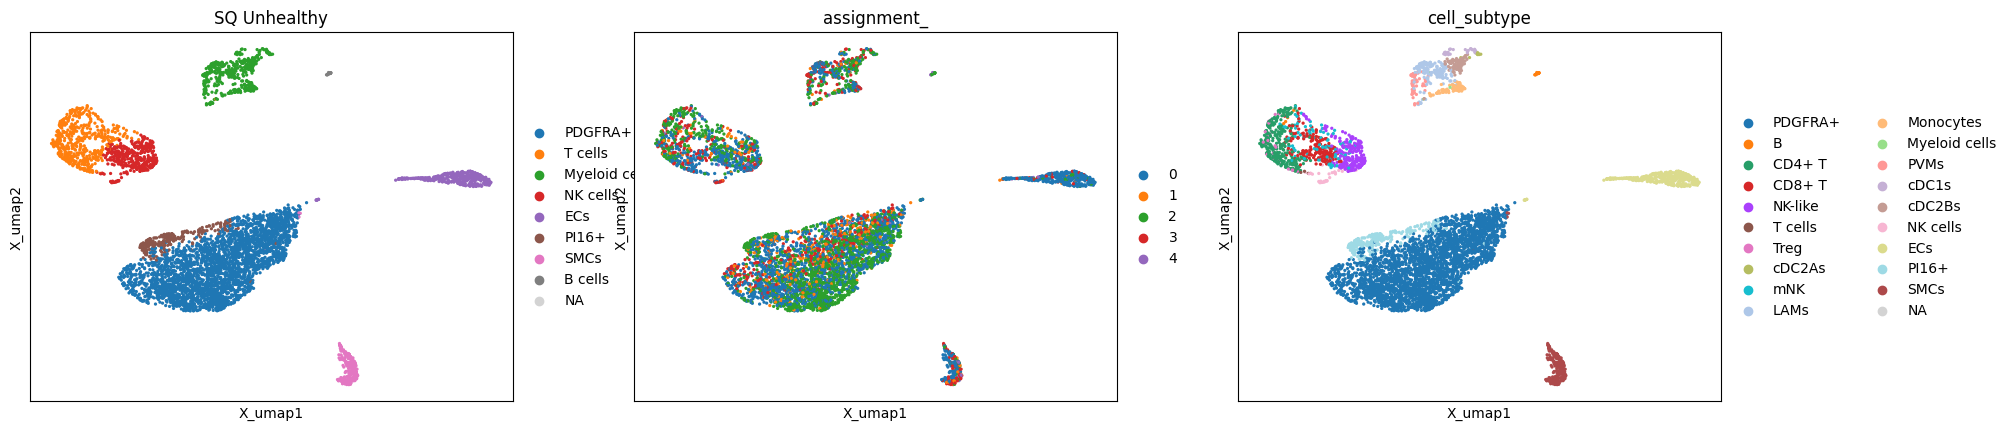

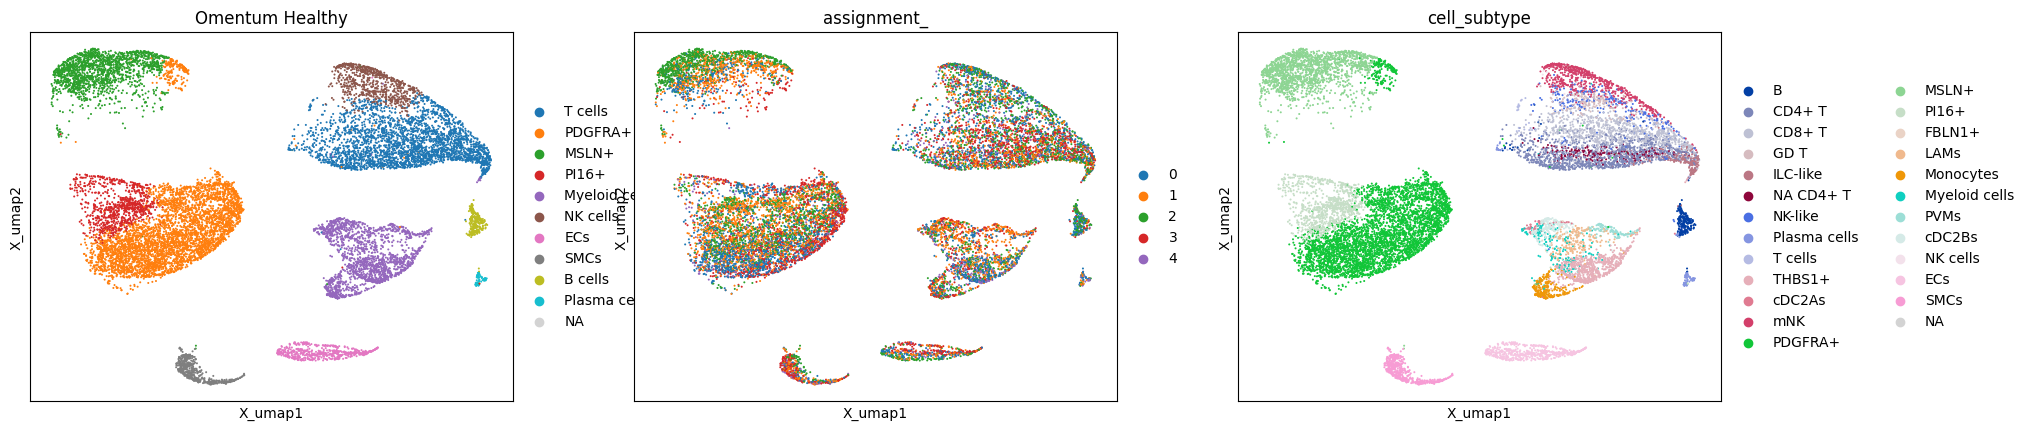

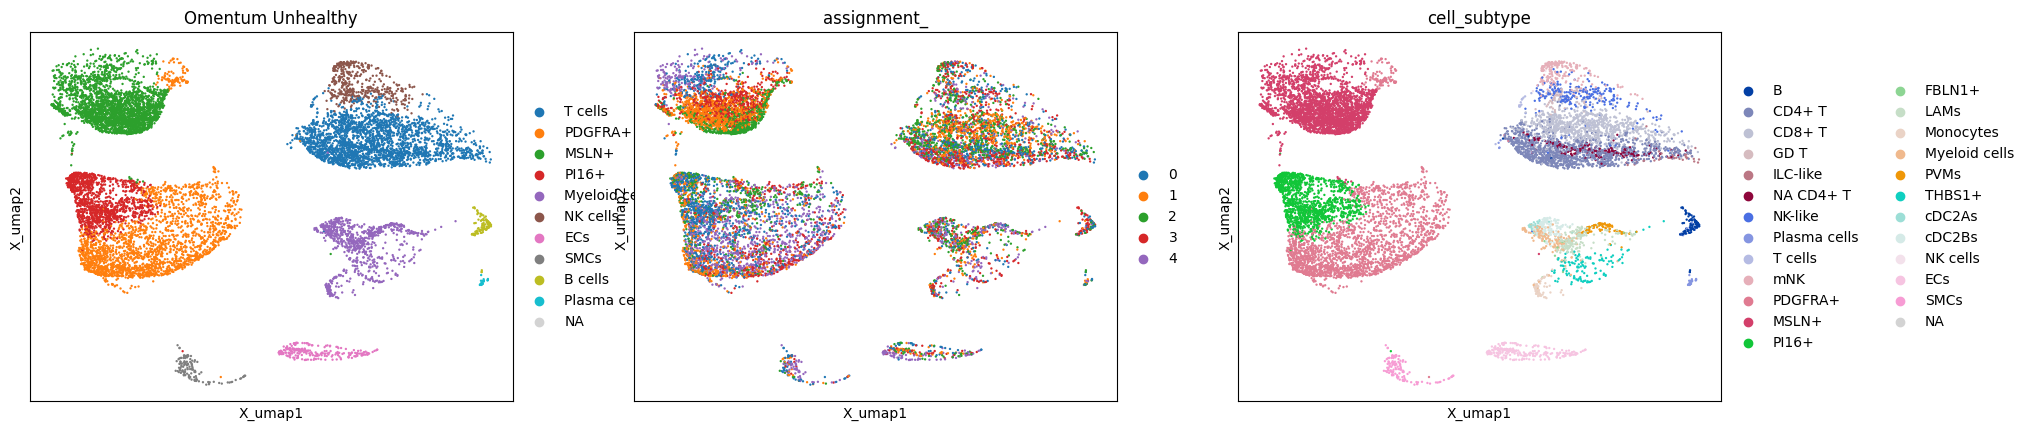

In [17]:
for sample_name, sample in samples.items():
    title = f'{sample["tissue"]} {sample["disease"]}'
    adata = sample["adata_sing"]
    # sc.experimental.pp.recipe_pearson_residuals(adata_sing, batch_key="assignment")
    
    # sc.pl.pca(adata_sing, color=["cell_type", "assignment"], title=title)
    # plt.show()

    # sc.pp.neighbors(adata_sing)
    # sc.tl.umap(adata_sing)
    # sc.pl.umap(adata_sing, color=["cell_type", "assignment"], title=title)
    
    sc.pl.embedding(adata, basis="X_umap", color=["cell_type", new_assign_col, "cell_subtype", ], title=title)
    plt.show()

In [19]:
for sample_name, sample in samples.items():
    sample["adata"].write_h5ad(os.path.join(INPUT_DIR, f"sc/{sample_name}.h5ad"))

## Counts by participant by cell-type

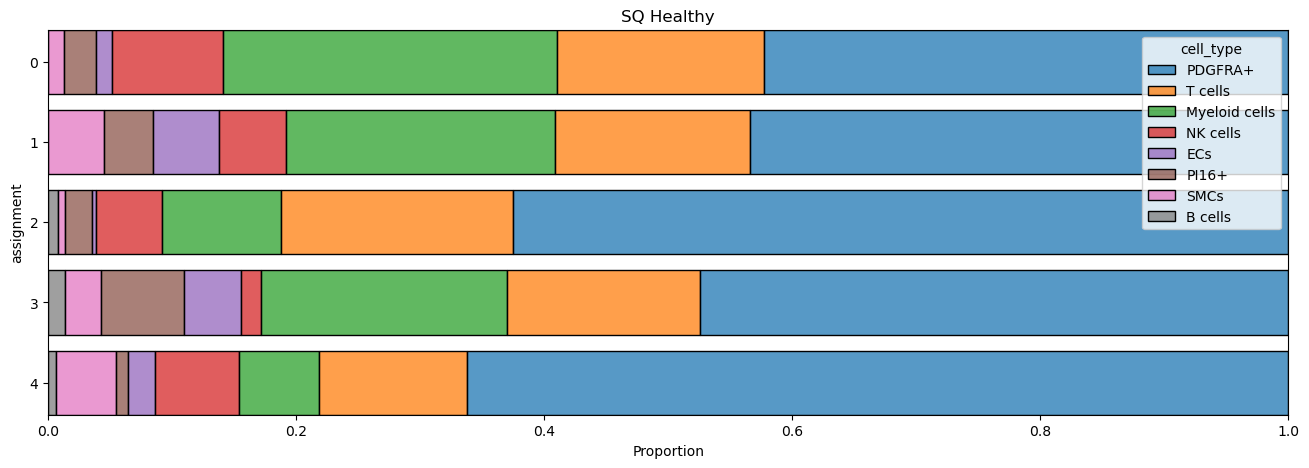

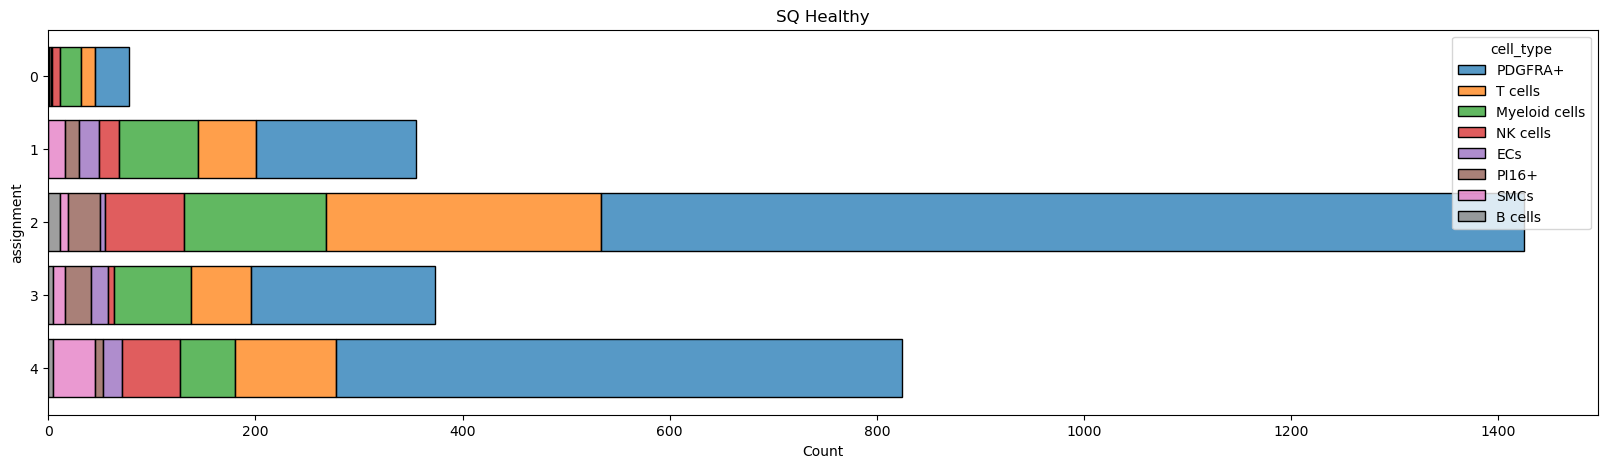

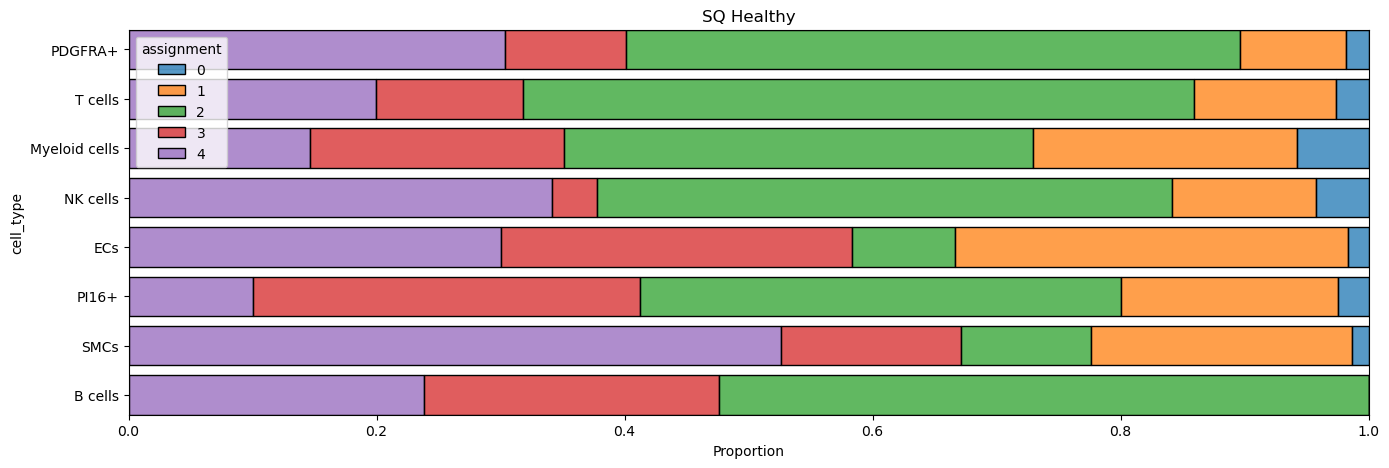

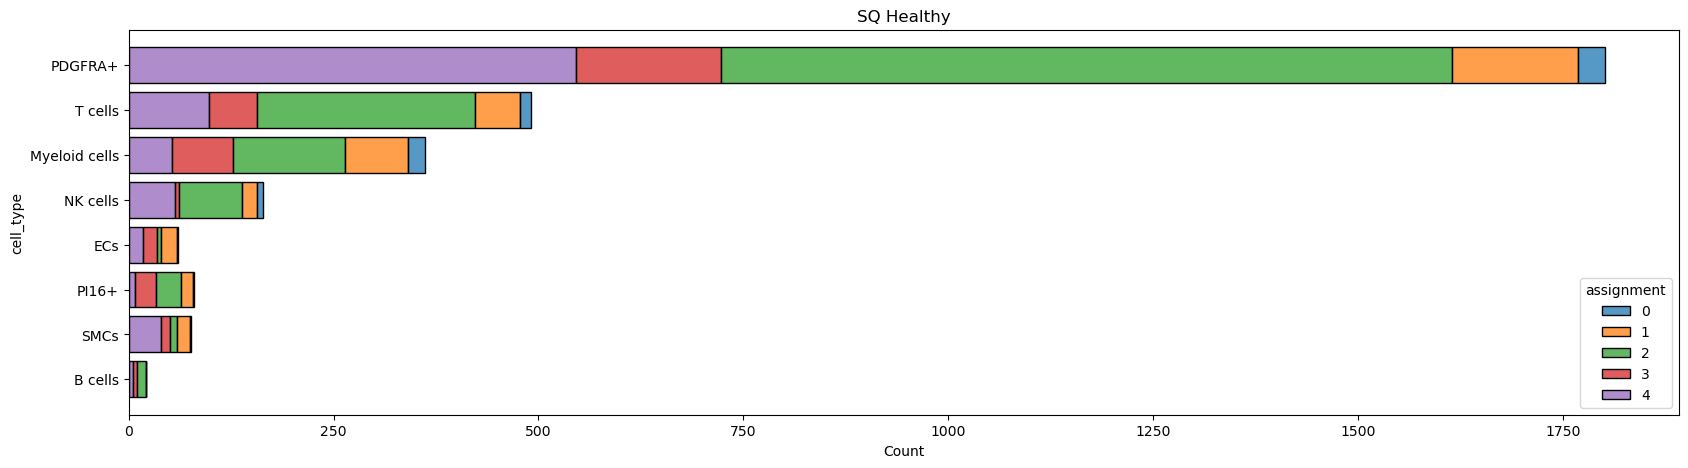

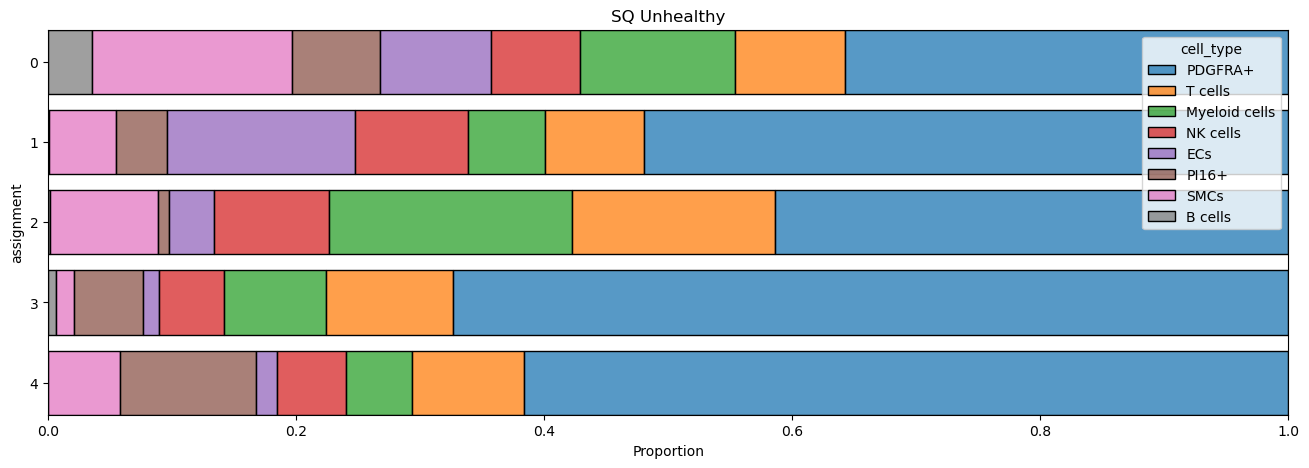

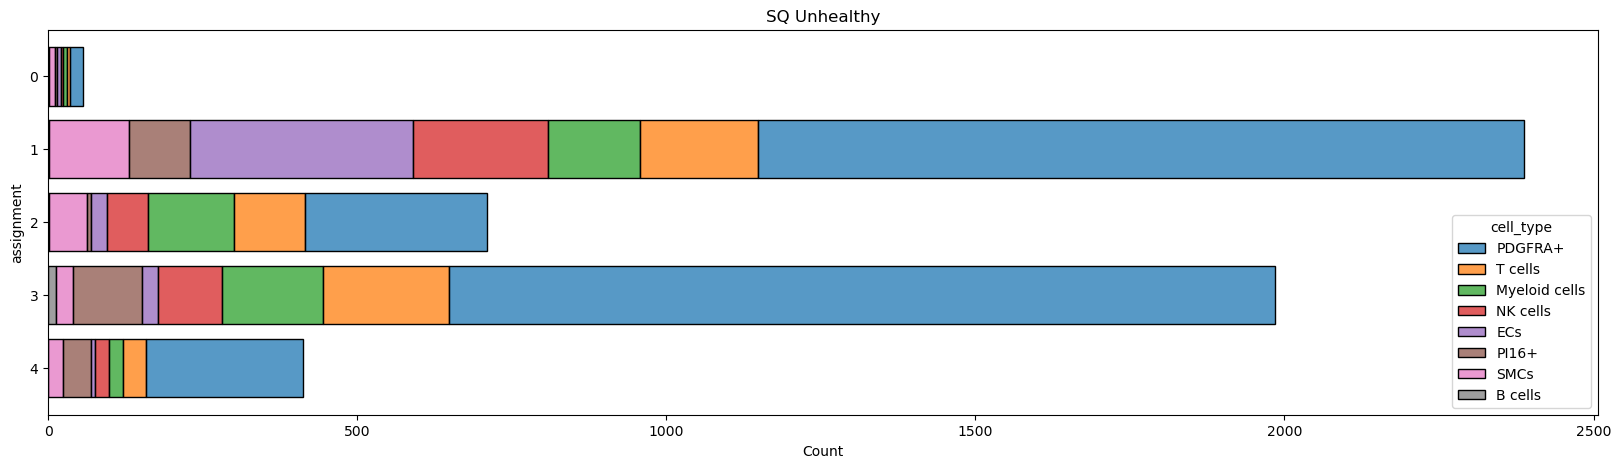

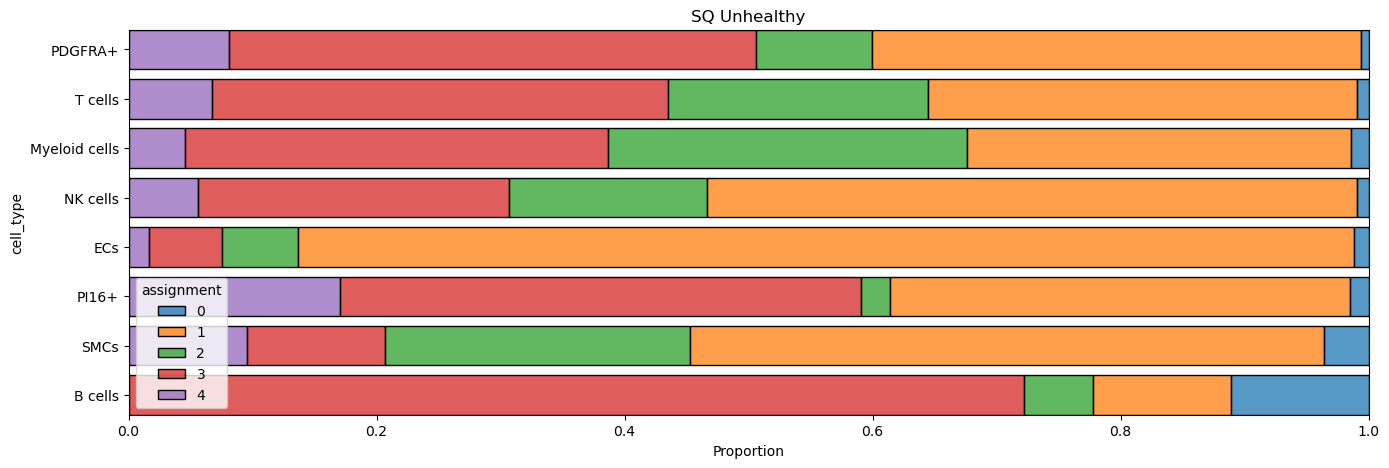

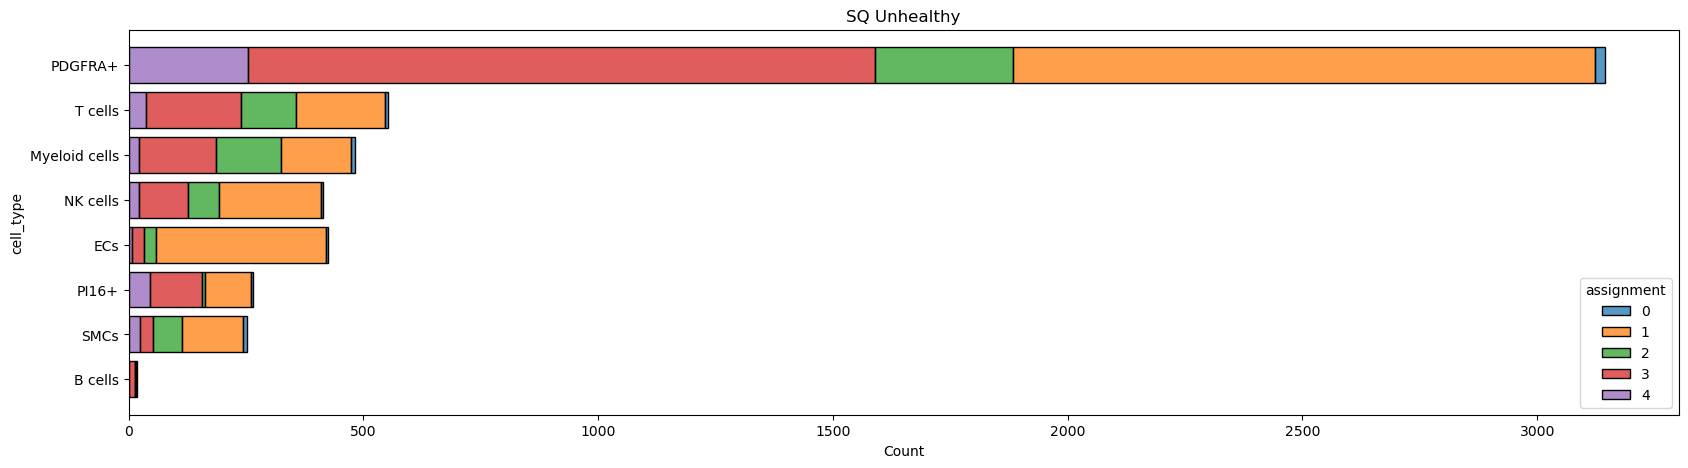

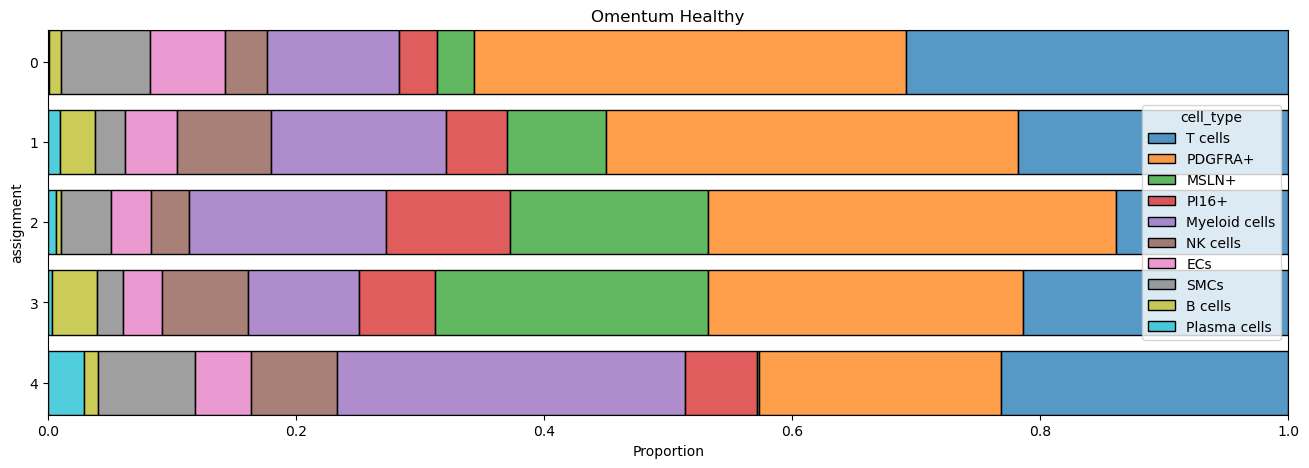

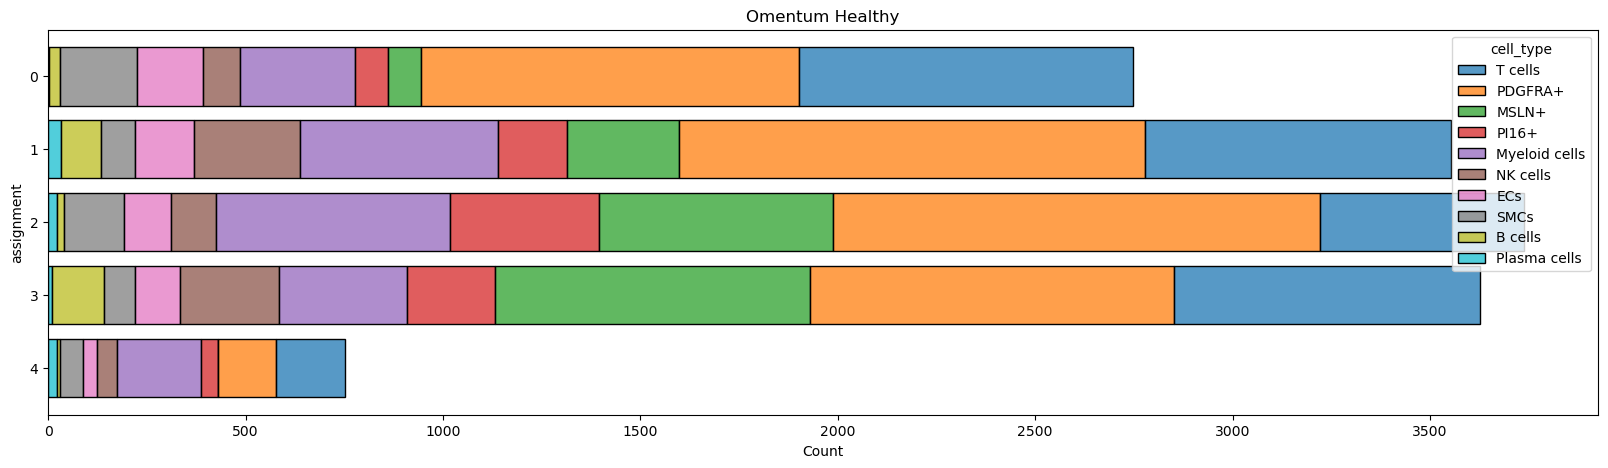

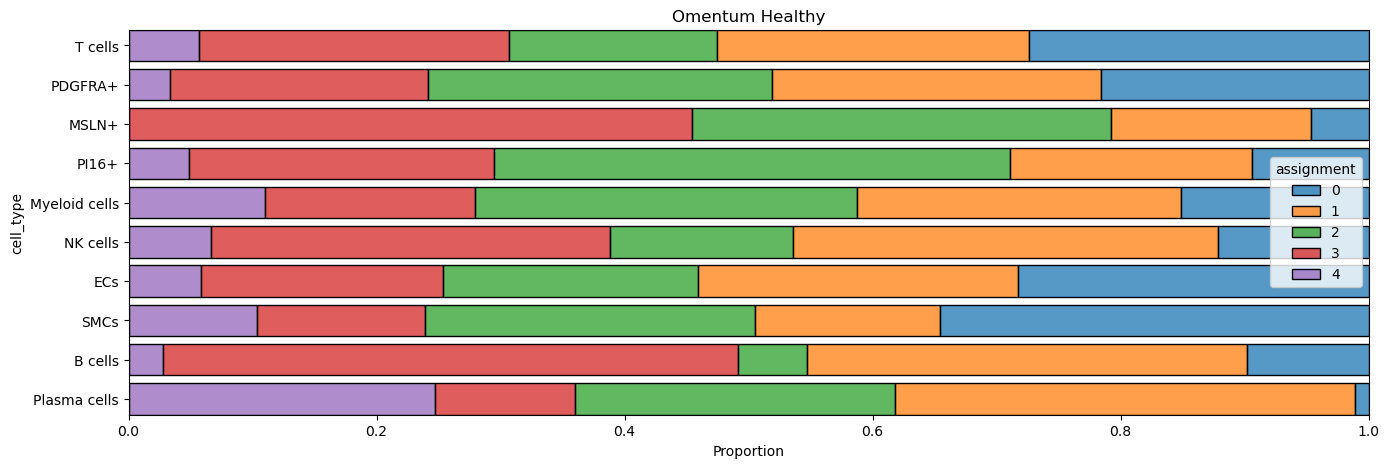

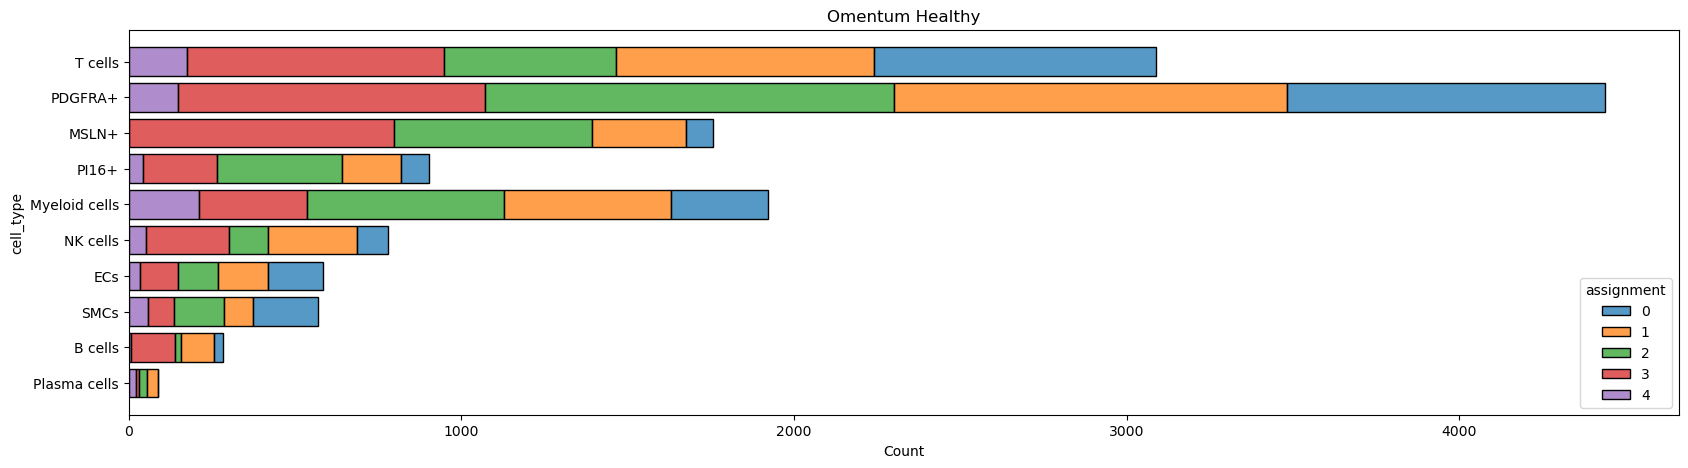

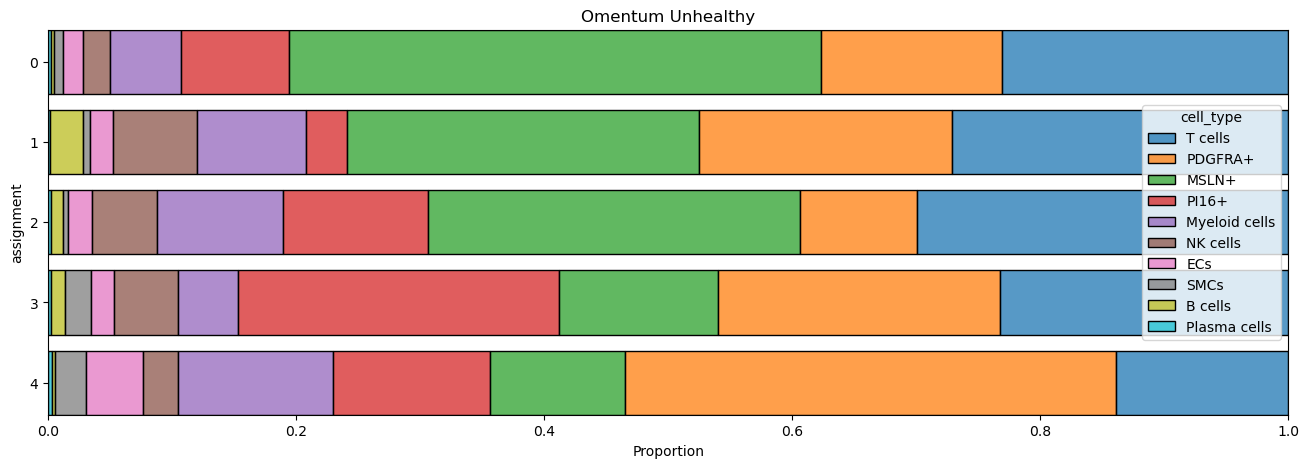

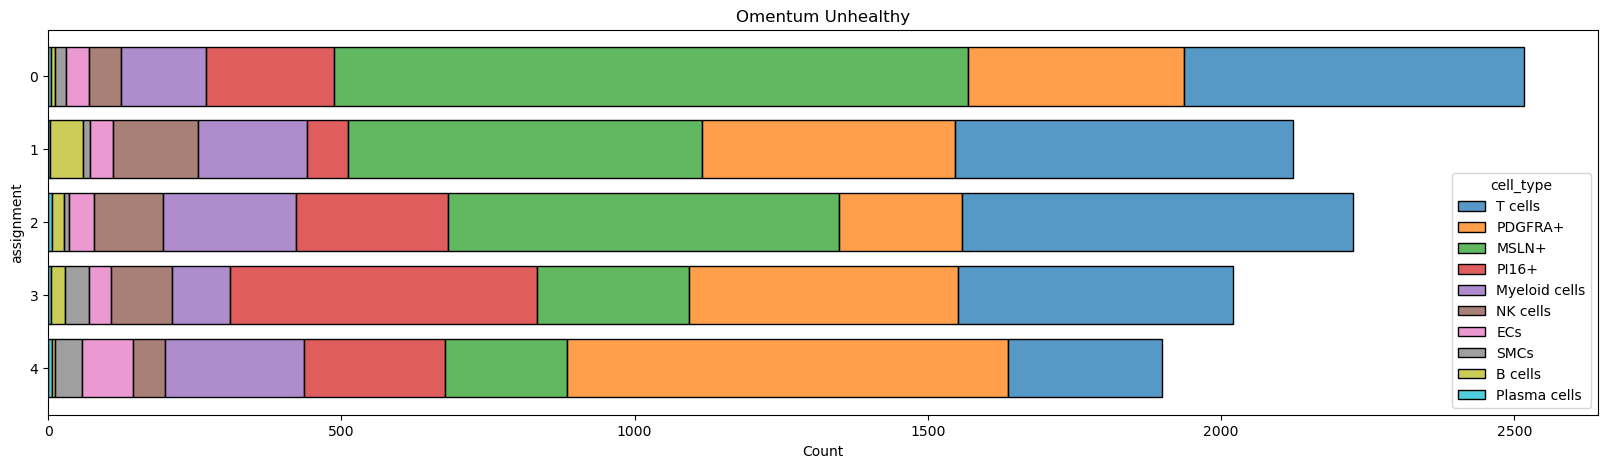

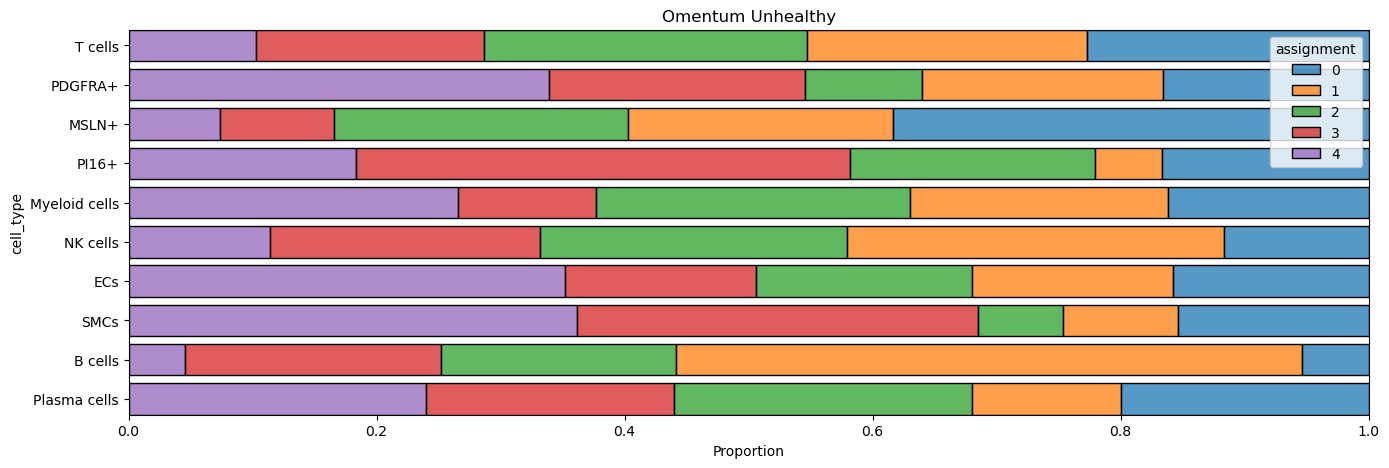

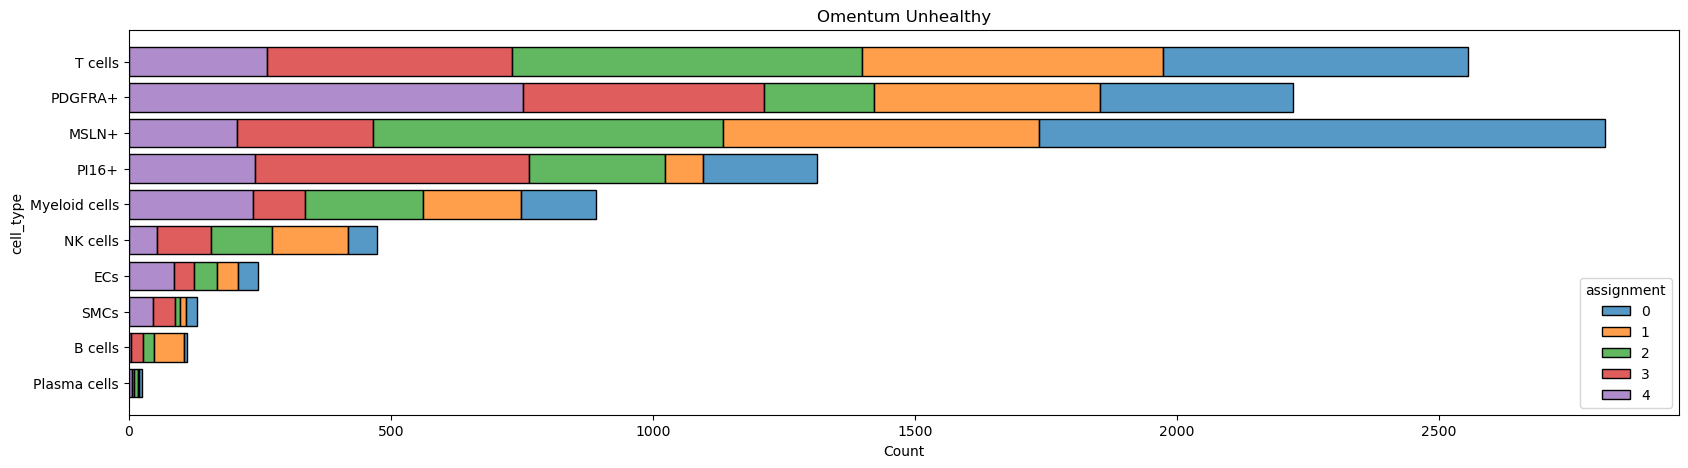

In [15]:
for sample in samples:
    
    adata_sing = sample["adata_sing"]
    title = f'{sample["tissue"]} {sample["disease"]}'
    
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata_sing.obs,
        y="assignment", hue="cell_type",
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata_sing.obs,
        y="assignment", hue="cell_type",
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata_sing.obs,
        y="cell_type", hue="assignment",
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata_sing.obs,
        y="cell_type", hue="assignment",
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

### TODO:
Can we present the split patient cell abundance as just average bars for each cell type to compare to the previous data

In [14]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


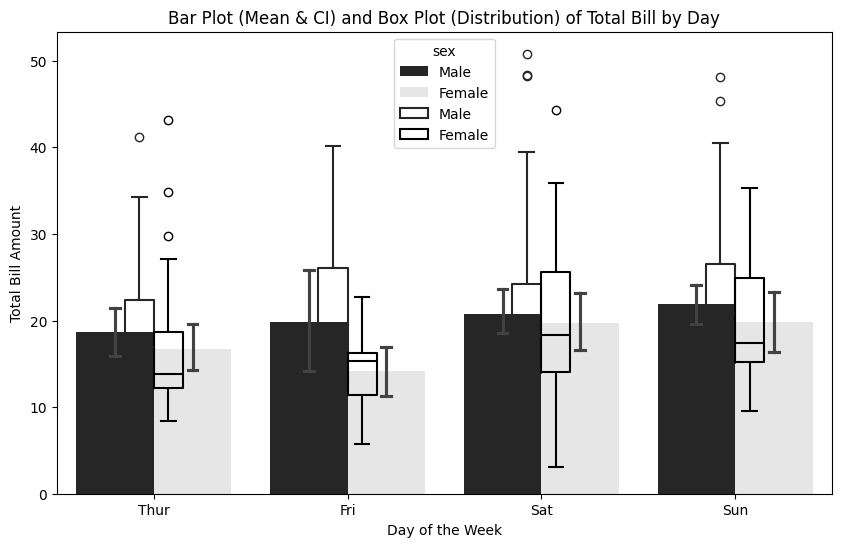

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load an example dataset
tips = sns.load_dataset("tips")

# Initialize the matplotlib figure and axes
# The figure size is adjusted to prevent crowding
plt.figure(figsize=(10, 6))
ax = plt.gca() # Get the current axes

# 1. Plot the bar plot
# By default, the barplot shows the mean and 95% confidence interval
sns.barplot(data=tips, x="day", y="total_bill", palette='dark:.9', ax=ax, capsize=0.1, saturation=0.1, hue="sex", )

# 2. Overlay the box plot
# Use a different color or "fill=False" for better visual separation
sns.boxplot(data=tips, x="day", y="total_bill", ax=ax, fill=False, palette='dark:black', width=0.3, hue="sex")

# Optional: Add titles and labels
plt.title("Bar Plot (Mean & CI) and Box Plot (Distribution) of Total Bill by Day")
plt.xlabel("Day of the Week")
plt.ylabel("Total Bill Amount")

# Display the plot
plt.show()


## Sex chromosome genotypes
Variants on Y chr and Y chr genes expression (except for PAR):  
Female: X chr variants can be homo and heterozygous, shouldn’t have Y chr variants called (except for PAR)  
Male: X chr variants should be homozygous (except for PAR), Y chr variants should be and should be homozygous

In [8]:
import vcfpy

#### separate samples

In [95]:
vcf_fps = glob.glob(os.path.join(INPUT_DIR, "demultiplex", "separate_samples", "*", "*.vcf.gz"))
vcf_fps

['inputs/demultiplex/separate_samples/BRI-1456/BRI-1456.cluster_genotypes.vcf.gz',
 'inputs/demultiplex/separate_samples/BRI-1458/BRI-1458.cluster_genotypes.vcf.gz',
 'inputs/demultiplex/separate_samples/BRI-1459/BRI-1459.cluster_genotypes.vcf.gz',
 'inputs/demultiplex/separate_samples/BRI-1457/BRI-1457.cluster_genotypes.vcf.gz']

In [96]:
# PAR regions:
# PAR1 chrX:10,000-2,781,479 and chrY:10,000-2,781,479
# PAR2 chrX:155,701,383-156,030,895 and chrY:56,887,902-57,217,415

##contig=<ID=chrX,length=156040895>
##contig=<ID=chrY,length=57227415>


unique_regions = {
   ("chrY", 2781480, 56887902), # is unique to Y
   ("chrY", 57217416, 57227415), # is unique to Y
   ("chrX", 2781480, 155701383), # is unique to X
   ("chrX", 156030896, 156040895) # is unique to X
}

In [99]:
sex_chr_genotypes = {}

sex_chr_genotypes_coverage = {}

for vcf_fp in vcf_fps:
    reader = vcfpy.Reader.from_path(vcf_fp)

    # Build and print header
    header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
    # print('\t'.join(header))

    lib_name = os.path.basename(vcf_fp).split(".")[0]

    sample_names = [f"{lib_name}_{sample_name}" for sample_name in reader.header.samples.names]

    
    for sample_name in sample_names:
        
        sex_chr_genotypes[sample_name] =  {
            "chrX_homo": 0,
            "chrX_hetero": 0,
            "chrY_homo": 0,
            "chrY_hetero": 0,
        }
        sex_chr_genotypes_coverage[sample_name] = {
            "chrX_homo": [],
            "chrX_hetero": [],
            "chrY_homo": [],
            "chrY_hetero": []
        }
        
    
    # n = 5
    # i = 0

    for region in unique_regions:
        for record in reader.fetch(*region):
            # if not record.is_snv():
                # continue
            # line = [record.CHROM, record.POS, record.REF]
            # line += [alt.value for alt in record.ALT]
            # line += [call.data.get('GT') or './.' for call in record.calls]
            # print('\t'.join(map(str, line)))

            for sample_name, call in zip(reader.header.samples.names, record.calls):
                
                sample_gt = call.data.get('GT') or './.'
                
                if sample_gt == './.':
                    continue
                    
                sample_gt_alts = [int(m) for m in sample_gt.split("/")]

                assert len(sample_gt_alts) == 2

                lib_sample_name = f"{lib_name}_{sample_name}"
                
                if sample_gt_alts[0] == sample_gt_alts[1]:
                    variant_type = f"{record.CHROM}_homo"
                else:
                    variant_type = f"{record.CHROM}_hetero"
                
                sex_chr_genotypes[lib_sample_name][variant_type] += 1

                if "RO" in call.data and call.data["RO"]:
                    sex_chr_genotypes_coverage[lib_sample_name][variant_type].append(call.data["RO"])
                
                if "AO" in call.data:
                    for ao in call.data["AO"]:
                        if ao:
                            sex_chr_genotypes_coverage[lib_sample_name][variant_type].append(ao)
        #     i += 1
            
        #     if i == n:
        #         break
        
        # if i == n:
        #     break
        # break

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT T not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT E not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GO not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GN not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/parser.py:515: UnknownFilter: Filter not found in header: BACKGROUND; problem in FILTER column
  warnings.warn(


Female: X chr variants can be homo and heterozygous, shouldn’t have Y chr variants called (except for PAR)  
Male: X chr variants should be homozygous (except for PAR), Y chr variants should be and should be homozygous

In [164]:
sex_chr_genotypes_df = pd.DataFrame.from_dict(sex_chr_genotypes, orient="index")
sex_chr_genotypes_df.sort_index()

,chrX_homo,chrX_hetero,chrY_homo,chrY_hetero
BRI-1456_0,357,21,15,1
BRI-1456_1,608,80,6,0
BRI-1456_2,633,116,30,6
BRI-1456_3,574,125,7,0
BRI-1456_4,527,221,7,0
BRI-1457_0,538,23,26,0
BRI-1457_1,1432,572,10,0
BRI-1457_2,1570,286,24,11
BRI-1457_3,1455,545,10,0
BRI-1457_4,1334,265,14,0


#### intercept samples

In [188]:
vcf_fps = glob.glob(os.path.join(INPUT_DIR, "demultiplex", "intercept_samples", "*", "*.vcf.gz"))
vcf_fps

['inputs/demultiplex/intercept_samples/BRI-1456/cluster_genotypes.vcf.gz',
 'inputs/demultiplex/intercept_samples/BRI-1458/cluster_genotypes.vcf.gz',
 'inputs/demultiplex/intercept_samples/BRI-1459/cluster_genotypes.vcf.gz',
 'inputs/demultiplex/intercept_samples/BRI-1457/cluster_genotypes.vcf.gz']

In [189]:
# PAR regions:
# PAR1 chrX:10,000-2,781,479 and chrY:10,000-2,781,479
# PAR2 chrX:155,701,383-156,030,895 and chrY:56,887,902-57,217,415

##contig=<ID=chrX,length=156040895>
##contig=<ID=chrY,length=57227415>


unique_regions = {
   ("chrY", 2781480, 56887902), # is unique to Y
   ("chrY", 57217416, 57227415), # is unique to Y
   ("chrX", 2781480, 155701383), # is unique to X
   ("chrX", 156030896, 156040895) # is unique to X
}

In [190]:
sex_chr_genotypes = {}

sex_chr_genotypes_coverage = {}

for vcf_fp in vcf_fps:
    reader = vcfpy.Reader.from_path(vcf_fp)

    # Build and print header
    header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
    # print('\t'.join(header))

    lib_name = os.path.basename(os.path.dirname(vcf_fp))

    sample_names = [f"{lib_name}_{sample_name}" for sample_name in reader.header.samples.names]

    
    for sample_name in sample_names:
        
        sex_chr_genotypes[sample_name] =  {
            "chrX_homo": 0,
            "chrX_hetero": 0,
            "chrY_homo": 0,
            "chrY_hetero": 0,
        }
        sex_chr_genotypes_coverage[sample_name] = {
            "chrX_homo": [],
            "chrX_hetero": [],
            "chrY_homo": [],
            "chrY_hetero": []
        }
        
    
    # n = 5
    # i = 0

    for region in unique_regions:
        for record in reader.fetch(*region):
            # if not record.is_snv():
                # continue
            # line = [record.CHROM, record.POS, record.REF]
            # line += [alt.value for alt in record.ALT]
            # line += [call.data.get('GT') or './.' for call in record.calls]
            # print('\t'.join(map(str, line)))

            for sample_name, call in zip(reader.header.samples.names, record.calls):
                
                sample_gt = call.data.get('GT') or './.'
                
                if sample_gt == './.':
                    continue
                    
                sample_gt_alts = [int(m) for m in sample_gt.split("/")]

                assert len(sample_gt_alts) == 2

                lib_sample_name = f"{lib_name}_{sample_name}"
                
                if sample_gt_alts[0] == sample_gt_alts[1]:
                    variant_type = f"{record.CHROM}_homo"
                else:
                    variant_type = f"{record.CHROM}_hetero"
                
                sex_chr_genotypes[lib_sample_name][variant_type] += 1

                if "RO" in call.data and call.data["RO"]:
                    sex_chr_genotypes_coverage[lib_sample_name][variant_type].append(call.data["RO"])
                
                if "AO" in call.data:
                    for ao in call.data["AO"]:
                        if ao:
                            sex_chr_genotypes_coverage[lib_sample_name][variant_type].append(ao)
        #     i += 1
            
        #     if i == n:
        #         break
        
        # if i == n:
        #     break
        # break

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT T not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT E not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GO not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GN not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/parser.py:515: UnknownFilter: Filter not found in header: BACKGROUND; problem in FILTER column
  warnings.warn(


Female: X chr variants can be homo and heterozygous, shouldn’t have Y chr variants called (except for PAR)  
Male: X chr variants should be homozygous (except for PAR), Y chr variants should be and should be homozygous

In [191]:
sex_chr_genotypes_df = pd.DataFrame.from_dict(sex_chr_genotypes, orient="index")
sex_chr_genotypes_df.sort_index()

,chrX_homo,chrX_hetero,chrY_homo,chrY_hetero
BRI-1456_0,246,12,9,1
BRI-1456_1,334,92,7,0
BRI-1456_2,384,72,11,5
BRI-1456_3,370,49,6,0
BRI-1456_4,311,145,7,0
BRI-1457_0,740,171,10,0
BRI-1457_1,682,385,8,0
BRI-1457_2,384,23,13,1
BRI-1457_3,850,167,13,5
BRI-1457_4,711,356,9,0


#### merge samples

In [5]:
vcf_fps = glob.glob(os.path.join(INPUT_DIR, "demultiplex", "merge_samples", "*", "*.vcf.gz"))
vcf_fps

['inputs/demultiplex/merge_samples/BRI-1456/cluster_genotypes.vcf.gz',
 'inputs/demultiplex/merge_samples/BRI-1458/cluster_genotypes.vcf.gz',
 'inputs/demultiplex/merge_samples/BRI-1459/cluster_genotypes.vcf.gz',
 'inputs/demultiplex/merge_samples/BRI-1457/cluster_genotypes.vcf.gz']

In [6]:
# PAR regions:
# PAR1 chrX:10,000-2,781,479 and chrY:10,000-2,781,479
# PAR2 chrX:155,701,383-156,030,895 and chrY:56,887,902-57,217,415

##contig=<ID=chrX,length=156040895>
##contig=<ID=chrY,length=57227415>


unique_regions = {
   ("chrY", 2781480, 56887902), # is unique to Y
   ("chrY", 57217416, 57227415), # is unique to Y
   ("chrX", 2781480, 155701383), # is unique to X
   ("chrX", 156030896, 156040895) # is unique to X
}

In [11]:
sex_chr_genotypes = {}

sex_chr_genotypes_coverage = {}

for vcf_fp in vcf_fps:
    reader = vcfpy.Reader.from_path(vcf_fp)

    # Build and print header
    header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
    # print('\t'.join(header))

    lib_name = os.path.basename(os.path.dirname(vcf_fp))

    sample_names = [f"{lib_name}_{sample_name}" for sample_name in reader.header.samples.names]

    
    for sample_name in sample_names:
        
        sex_chr_genotypes[sample_name] =  {
            "chrX_homo": 0,
            "chrX_hetero": 0,
            "chrY_homo": 0,
            "chrY_hetero": 0,
        }
        sex_chr_genotypes_coverage[sample_name] = {
            "chrX_homo": [],
            "chrX_hetero": [],
            "chrY_homo": [],
            "chrY_hetero": []
        }
        
    
    # n = 5
    # i = 0

    for region in unique_regions:
        for record in reader.fetch(*region):
            # if not record.is_snv():
                # continue
            # line = [record.CHROM, record.POS, record.REF]
            # line += [alt.value for alt in record.ALT]
            # line += [call.data.get('GT') or './.' for call in record.calls]
            # print('\t'.join(map(str, line)))

            for sample_name, call in zip(reader.header.samples.names, record.calls):
                
                sample_gt = call.data.get('GT') or './.'
                
                if sample_gt == './.':
                    continue
                    
                sample_gt_alts = [int(m) for m in sample_gt.split("/")]

                assert len(sample_gt_alts) == 2

                lib_sample_name = f"{lib_name}_{sample_name}"
                
                if sample_gt_alts[0] == sample_gt_alts[1]:
                    variant_type = f"{record.CHROM}_homo"
                else:
                    variant_type = f"{record.CHROM}_hetero"
                
                sex_chr_genotypes[lib_sample_name][variant_type] += 1

                if "RO" in call.data and call.data["RO"]:
                    sex_chr_genotypes_coverage[lib_sample_name][variant_type].append(call.data["RO"])
                
                if "AO" in call.data:
                    for ao in call.data["AO"]:
                        if ao:
                            sex_chr_genotypes_coverage[lib_sample_name][variant_type].append(ao)
        #     i += 1
            
        #     if i == n:
        #         break
        
        # if i == n:
        #     break
        # break

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT T not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT E not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GO not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GN not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/parser.py:515: UnknownFilter: Filter not found in header: BACKGROUND; problem in FILTER column
  warnings.warn(


Female: X chr variants can be homo and heterozygous, shouldn’t have Y chr variants called (except for PAR)  
Male: X chr variants should be homozygous (except for PAR), Y chr variants should be and should be homozygous

In [12]:
sex_chr_genotypes_df = pd.DataFrame.from_dict(sex_chr_genotypes, orient="index")
sex_chr_genotypes_df.sort_index()

,chrX_homo,chrX_hetero,chrY_homo,chrY_hetero
BRI-1456_0,2404,659,19,0
BRI-1456_1,1669,226,14,0
BRI-1456_2,1780,148,9,1
BRI-1456_3,709,26,64,4
BRI-1456_4,3092,626,116,128
BRI-1457_0,4386,1929,24,1
BRI-1457_1,2529,336,13,0
BRI-1457_2,4338,1496,17,0
BRI-1457_3,3625,497,73,87
BRI-1457_4,817,26,50,10


In [101]:
# sex_chr_genotypes_df[["lib_name", "sample_name"]] = sex_chr_genotypes_df.index.to_series().str.split("_", expand=True)

In [102]:
# sex_chr_genotypes_df["sample_name"] = pd.Categorical(sex_chr_genotypes_df["sample_name"])

### By Y chromosome variants coverage

In [147]:
samples_sex = """BRI-1456_0 M
BRI-1456_1 F
BRI-1456_2 M
BRI-1456_3 F
BRI-1456_4 F
BRI-1457_0 M
BRI-1457_1 F
BRI-1457_2 M
BRI-1457_3 F
BRI-1457_4 F
BRI-1458_0 M
BRI-1458_1 F
BRI-1458_2 F
BRI-1458_3 M
BRI-1458_4 F
BRI-1459_0 F
BRI-1459_1 M
BRI-1459_2 M
BRI-1459_3 F
BRI-1459_4 F""".split("\n")

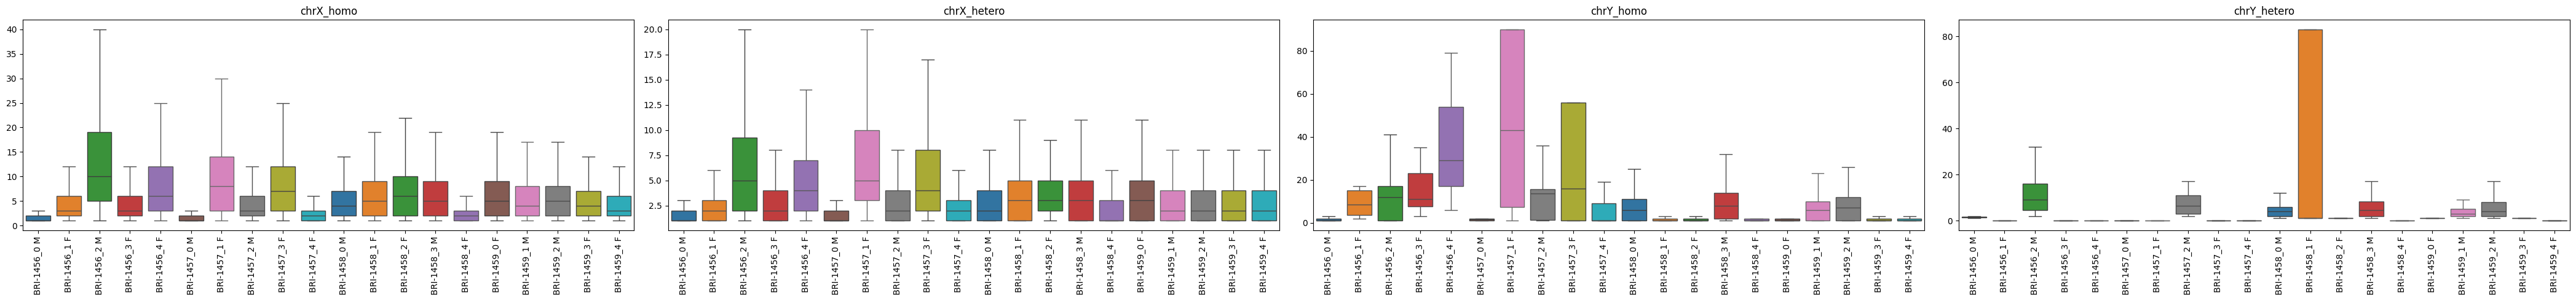

In [165]:
fig, axs = plt.subplots(1, len(sample_coverages), figsize=(42, 5))

j = 0

for sample_sex in samples_sex:
    sample_name = sample_sex.split(" ")[0]
    sample_coverages = sex_chr_genotypes_coverage[sample_name]
    i = 0
    
    for genotype_type in sex_chr_genotypes_df.columns:

        genotype_coverage = sample_coverages[genotype_type]
        if not genotype_coverage:
            sns.boxplot(y=[0], x=j, ax=axs[i], label=sample_name, showfliers=False)
        
        else:
            sns.boxplot(y=genotype_coverage, x=j, ax=axs[i], label=sample_name, showfliers=False)
        
        # _ = axs[i].legend(loc='center left', bbox_to_anchor=(5, 0.5))
        
        axs[i].set_title(genotype_type)
        axs[i].set_xticks(range(len(sex_chr_genotypes_coverage)))
        axs[i].set_xticklabels(samples_sex)
        axs[i].tick_params("x", labelrotation=90)
        # if i == (len(sample_coverages) - 1):
            # _ = axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
        # else:
        _ = axs[i].legend_.remove()
        
        i += 1
    j += 1


fig.tight_layout()

### By Y chromosome genes coverage

In [28]:
# from pyensembl import EnsemblRelease

# # Initialize EnsemblRelease object for human, GRCh38, Ensembl release 105
# data = EnsemblRelease(
#     # release=105,
#     # species='homo_sapiens',
#     # genome_assembly='GRCh38'
# )

# # Download the data (if not already downloaded)
# data.download()

In [28]:
ensembl_gtf_fp = "/n/groups/kirschner/reference/human/hg38/ensembl/Homo_sapiens.GRCh38.102.gtf"

ensembl_gtf = pd.read_csv(ensembl_gtf_fp, sep="\t", comment="#", header=None)
ensembl_gtf["gene_id"] = ensembl_gtf.iloc[:,8].str.extract('gene_id "(\w+)"')
ensembl_gtf

/tmp/ipykernel_3458694/3387369112.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ensembl_gtf = pd.read_csv(ensembl_gtf_fp, sep="\t", comment="#", header=None)


,0,1,2,3,4,5,6,7,8,gene_id
0,1,havana,gene,11869,14409,.,+,.,"gene_id ""ENSG00000223972""; gene_version ""5""; g...",ENSG00000223972
1,1,havana,transcript,11869,14409,.,+,.,"gene_id ""ENSG00000223972""; gene_version ""5""; t...",ENSG00000223972
2,1,havana,exon,11869,12227,.,+,.,"gene_id ""ENSG00000223972""; gene_version ""5""; t...",ENSG00000223972
3,1,havana,exon,12613,12721,.,+,.,"gene_id ""ENSG00000223972""; gene_version ""5""; t...",ENSG00000223972
4,1,havana,exon,13221,14409,.,+,.,"gene_id ""ENSG00000223972""; gene_version ""5""; t...",ENSG00000223972
...,...,...,...,...,...,...,...,...,...,...
3010590,KI270713.1,ensembl,transcript,35407,35916,.,+,.,"gene_id ""ENSG00000268674""; gene_version ""2""; t...",ENSG00000268674
3010591,KI270713.1,ensembl,exon,35407,35916,.,+,.,"gene_id ""ENSG00000268674""; gene_version ""2""; t...",ENSG00000268674
3010592,KI270713.1,ensembl,CDS,35407,35913,.,+,0,"gene_id ""ENSG00000268674""; gene_version ""2""; t...",ENSG00000268674
3010593,KI270713.1,ensembl,start_codon,35407,35409,.,+,0,"gene_id ""ENSG00000268674""; gene_version ""2""; t...",ENSG00000268674


In [29]:
ensembl_gtf.value_counts(2)

2
exon               1429266
CDS                 789946
transcript          232024
three_prime_utr     167723
five_prime_utr      157872
start_codon          90054
stop_codon           82918
gene                 60675
Selenocysteine         117
Name: count, dtype: int64

In [30]:
ensembl_gtf.loc[ensembl_gtf.gene_id == "ENSG00000271895",:]

,0,1,2,3,4,5,6,7,8,gene_id
22458,1,havana,gene,11029659,11030528,.,+,.,"gene_id ""ENSG00000271895""; gene_version ""2""; g...",ENSG00000271895
22459,1,havana,transcript,11029659,11030528,.,+,.,"gene_id ""ENSG00000271895""; gene_version ""2""; t...",ENSG00000271895
22460,1,havana,exon,11029659,11030528,.,+,.,"gene_id ""ENSG00000271895""; gene_version ""2""; t...",ENSG00000271895
22461,1,havana,transcript,11029758,11030528,.,+,.,"gene_id ""ENSG00000271895""; gene_version ""2""; t...",ENSG00000271895
22462,1,havana,exon,11029758,11029781,.,+,.,"gene_id ""ENSG00000271895""; gene_version ""2""; t...",ENSG00000271895
22463,1,havana,exon,11029902,11030528,.,+,.,"gene_id ""ENSG00000271895""; gene_version ""2""; t...",ENSG00000271895


In [31]:
ensembl_genes = ensembl_gtf.loc[ensembl_gtf[2] == "gene",:].copy()
ensembl_genes

,0,1,2,3,4,5,6,7,8,gene_id
0,1,havana,gene,11869,14409,.,+,.,"gene_id ""ENSG00000223972""; gene_version ""5""; g...",ENSG00000223972
12,1,havana,gene,14404,29570,.,-,.,"gene_id ""ENSG00000227232""; gene_version ""5""; g...",ENSG00000227232
25,1,mirbase,gene,17369,17436,.,-,.,"gene_id ""ENSG00000278267""; gene_version ""1""; g...",ENSG00000278267
28,1,havana,gene,29554,31109,.,+,.,"gene_id ""ENSG00000243485""; gene_version ""5""; g...",ENSG00000243485
36,1,mirbase,gene,30366,30503,.,+,.,"gene_id ""ENSG00000284332""; gene_version ""1""; g...",ENSG00000284332
...,...,...,...,...,...,...,...,...,...,...
3010424,KI270711.1,ensembl,gene,4612,29626,.,-,.,"gene_id ""ENSG00000271254""; gene_version ""6""; g...",ENSG00000271254
3010575,KI270713.1,ensembl,gene,21861,22024,.,-,.,"gene_id ""ENSG00000275405""; gene_version ""1""; g...",ENSG00000275405
3010578,KI270713.1,ensembl,gene,30437,30580,.,-,.,"gene_id ""ENSG00000275987""; gene_version ""1""; g...",ENSG00000275987
3010581,KI270713.1,ensembl,gene,31698,32528,.,-,.,"gene_id ""ENSG00000277475""; gene_version ""1""; g...",ENSG00000277475


In [32]:
adata.var[["chr", "start", "end", "strand"]] = ensembl_genes.set_index("gene_id").loc[adata.var.gene_ids, [0, 3, 4, 6]]

KeyError: "['ENSG00000225986', 'ENSG00000270040', 'ENSG00000262180', 'ENSG00000228106', 'ENSG00000213029', 'ENSG00000224959', 'ENSG00000273466', 'ENSG00000272644', 'ENSG00000267034', 'ENSG00000285399', 'ENSG00000288436', 'ENSG00000272440', 'ENSG00000288380', 'ENSG00000286094', 'ENSG00000272308', 'ENSG00000233844', 'ENSG00000223821', 'ENSG00000232311', 'ENSG00000238202', 'ENSG00000267697', 'ENSG00000269899', 'ENSG00000183729', 'ENSG00000274956', 'ENSG00000234229', 'ENSG00000272593', 'ENSG00000268050', 'ENSG00000241084', 'ENSG00000231483', 'ENSG00000228951', 'ENSG00000204683', 'ENSG00000273038', 'ENSG00000274897', 'ENSG00000215159', 'ENSG00000257613', 'ENSG00000232243', 'ENSG00000256050', 'ENSG00000274307', 'ENSG00000259618', 'ENSG00000259298', 'ENSG00000262890', 'ENSG00000272923', 'ENSG00000230971', 'ENSG00000264608', 'ENSG00000204282', 'ENSG00000267702', 'ENSG00000272746', 'ENSG00000183791', 'ENSG00000278674', 'ENSG00000274744', 'ENSG00000268262', 'ENSG00000268423', 'ENSG00000267776', 

### check in bulk RNAseq

In [103]:
INPUT_DIR

'inputs'

In [170]:
bulk_vcf_fps = glob.glob(os.path.join(INPUT_DIR, "bulk_vcfs", "*.vcf.gz"))

In [171]:
bulk_sex_chr_genotypes = {}

bulk_sex_chr_genotypes_coverage = {}

for vcf_fp in bulk_vcf_fps:
    sample_name = os.path.basename(vcf_fp).split(".")[0]
    reader = vcfpy.Reader.from_path(vcf_fp)

    # Build and print header
    header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
    # print('\t'.join(header))
    
    bulk_sex_chr_genotypes[sample_name] =  {
        "chrX_homo": 0,
        "chrX_hetero": 0,
        "chrY_homo": 0,
        "chrY_hetero": 0,
    }
    bulk_sex_chr_genotypes_coverage[sample_name] = {
        "chrX_homo": [],
        "chrX_hetero": [],
        "chrY_homo": [],
        "chrY_hetero": []
    }
    
    
    # n = 3
    # i = 0

    assert len(reader.header.samples.names) == 1, reader.header.samples.names
    
    for region in unique_regions:
        for record in reader.fetch(*region):
            # if not record.is_snv():
                # continue
            # line = [record.CHROM, record.POS, record.REF]
            # line += [alt.value for alt in record.ALT]
            # line += [call.data.get('GT') or './.' for call in record.calls]
            # print('\t'.join(map(str, line)))

            call = record.calls[0]
                
            sample_gt = call.data.get('GT') or './.'
            
            if sample_gt == './.':
                continue
                
            sample_gt_alts = [int(m) for m in sample_gt.split("/")]

            assert len(sample_gt_alts) == 2
            
            if sample_gt_alts[0] == sample_gt_alts[1]:
                variant_type = f"{record.CHROM}_homo"
            else:
                variant_type = f"{record.CHROM}_hetero"
            
            bulk_sex_chr_genotypes[sample_name][variant_type] += 1

            if "RO" in call.data and call.data["RO"]:
                bulk_sex_chr_genotypes_coverage[sample_name][variant_type].append(call.data["RO"])
            
            if "AO" in call.data:
                for ao in call.data["AO"]:
                    if ao:
                        bulk_sex_chr_genotypes_coverage[sample_name][variant_type].append(ao)
        #     i += 1
            
        #     if i == n:
        #         break
        
        # if i == n:
        #     break
        # break

In [ ]:
# bluk RNA samples:

P22	MHO	M132048	M
P33	MHO	M133630	M
P34	MHO	M133143	F
P19	MHO	O779557	F
P35	MHO	M133475	F
P30	MUO	M133472	F
P20	MUO	M131973	M
P25	MUO	O510408	F
P27	MUO	O754925	F
P40	MUO	1030119	M

In [172]:
bulk_sex_chr_genotypes_df = pd.DataFrame.from_dict(bulk_sex_chr_genotypes, orient="index")
bulk_sex_chr_genotypes_df.sort_index()

,chrX_homo,chrX_hetero,chrY_homo,chrY_hetero
20220114_L25_LL9464_S24,4767,5199,546,1200
20220114_O19_LL9464_S1,5603,4986,512,1035
20220114_O20_LL9464_S2,7928,8791,379,1398
20220114_O22_LL9464_S3,6467,5370,595,2117
20220114_O25_LL9464_S4,5337,5302,416,944
20220114_O30_LL9464_S6,5955,12109,41,5
20220114_O33_LL9464_S7,5567,2979,930,2227
20220114_O35_LL9464_S9,6723,12059,40,2
20220114_S19_LL9464_S11,6478,9505,160,321
20220114_S30_LL9464_S16,4140,4968,32,0


In [174]:
bulk_samples_sex = """20220114_L25_LL9464_S24 F
20220114_O19_LL9464_S1 F
20220114_O20_LL9464_S2 M
20220114_O22_LL9464_S3 M
20220114_O25_LL9464_S4 F
20220114_O30_LL9464_S6 F
20220114_O33_LL9464_S7 M
20220114_O35_LL9464_S9 F
20220114_S19_LL9464_S11 F
20220114_S30_LL9464_S16 F
20220114_S35_LL9464_S19 F""".split("\n")

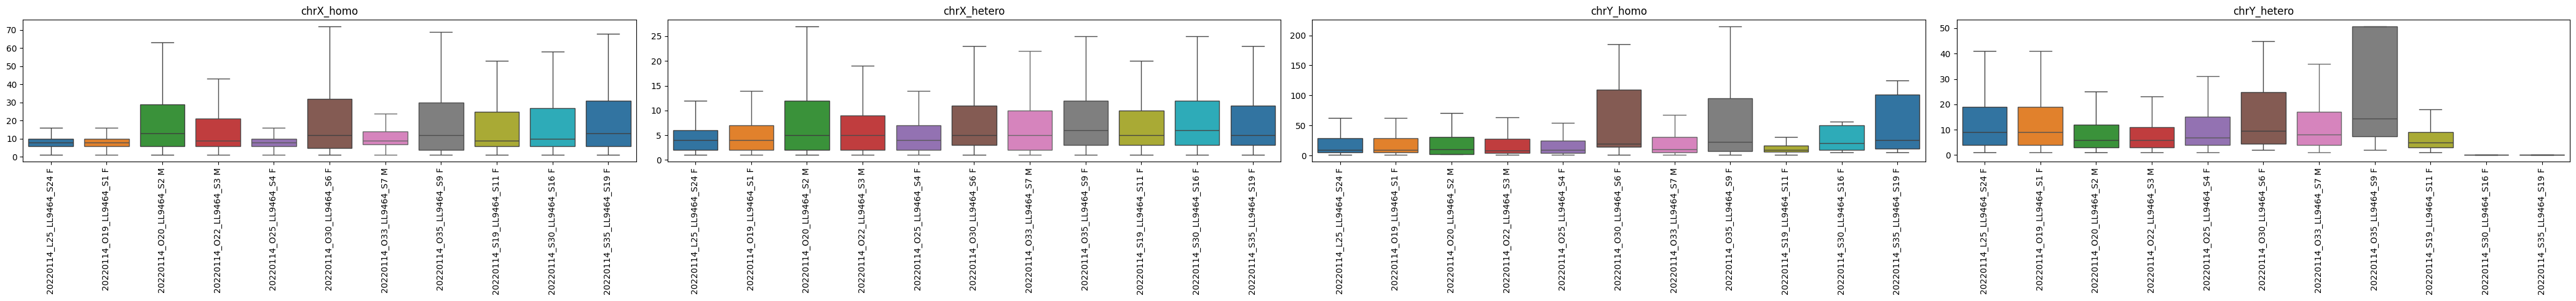

In [175]:
fig, axs = plt.subplots(1, len(sample_coverages), figsize=(42, 5))

j = 0

for sample_sex in bulk_samples_sex:
    sample_name = sample_sex.split(" ")[0]
    sample_coverages = bulk_sex_chr_genotypes_coverage[sample_name]
    i = 0
    
    for genotype_type in bulk_sex_chr_genotypes_df.columns:

        genotype_coverage = sample_coverages[genotype_type]
        if not genotype_coverage:
            sns.boxplot(y=[0], x=j, ax=axs[i], label=sample_name, showfliers=False)
        
        else:
            sns.boxplot(y=genotype_coverage, x=j, ax=axs[i], label=sample_name, showfliers=False)
        
        # _ = axs[i].legend(loc='center left', bbox_to_anchor=(5, 0.5))
        
        axs[i].set_title(genotype_type)
        axs[i].set_xticks(range(len(bulk_sex_chr_genotypes_df)))
        axs[i].set_xticklabels(bulk_samples_sex)
        axs[i].tick_params("x", labelrotation=90)
        # if i == (len(sample_coverages) - 1):
            # _ = axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
        # else:
        _ = axs[i].legend_.remove()
        
        i += 1
    j += 1


fig.tight_layout()

# Separate samples SNPs intersection between tissue types

In [20]:
import glob

import vcfpy

import numpy as np

In [5]:
# for bed_fp in glob.glob(os.path.join(INPUT_DIR, "demultiplex", "*.cluster_genotypes.SNP.bed")):
#     bed = pd.read_csv(bed_fp, sep="\t", header=None) #, skiprows=2)
#     # bed.iloc[:,2] = bed.iloc[:,1]
#     bed.iloc[:,2] = bed.iloc[:,1]
#     bed.iloc[:,1] -= 1
#     # bed.iloc[:,1] += 1
#     bed.to_csv(bed_fp, sep="\t", index=False, header=False)

In [28]:
vcf_fp = os.path.join(INPUT_DIR, "demultiplex", "BRI-1456.BRI-1457.cluster_genotypes.SNP.vcf")
reader = vcfpy.Reader.from_path(vcf_fp)

# Build and print header
header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
print('\t'.join(header))


n = 10
i = 0

for record in reader:
    if not record.is_snv():
        continue
    line = [record.CHROM, record.POS, record.REF]
    line += [alt.value for alt in record.ALT]
    line += [call.data.get('GT') or './.' for call in record.calls]
    print('\t'.join(map(str, line)))
    i += 1
    if i == n:
        break

#CHROM	POS	REF	ALT	0	1	2	3	4
chr1	629906	C	T	1/1	1/1	1/1	1/1	1/1
chr1	841742	A	T	1/1	1/1	0/1	1/1	0/1
chr1	944296	G	A	./.	1/1	1/1	1/1	1/1
chr1	944307	T	C	./.	1/1	1/1	1/1	1/1
chr1	944531	G	A	0/1	0/1	0/1	0/0	0/1
chr1	958251	A	G	./.	1/1	1/1	1/1	1/1
chr1	958339	G	A	1/1	1/1	1/1	1/1	1/1
chr1	965592	T	G	./.	1/1	1/1	1/1	1/1
chr1	1014228	G	A	0/1	0/0	1/1	0/0	0/1
chr1	1014274	A	G	1/1	1/1	1/1	1/1	1/1


In [29]:
vcf_fp = os.path.join(INPUT_DIR, "demultiplex", "BRI-1457.BRI-1456.cluster_genotypes.SNP.vcf")
reader = vcfpy.Reader.from_path(vcf_fp)

# Build and print header
header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
print('\t'.join(header))


n = 10
i = 0

for record in reader:
    if not record.is_snv():
        continue
    line = [record.CHROM, record.POS, record.REF]
    line += [alt.value for alt in record.ALT]
    line += [call.data.get('GT') or './.' for call in record.calls]
    print('\t'.join(map(str, line)))
    i += 1
    if i == n:
        break

#CHROM	POS	REF	ALT	0	1	2	3	4
chr1	629906	C	T	./.	1/1	1/1	1/1	1/1
chr1	841742	A	T	./.	1/1	1/1	0/0	1/1
chr1	944296	G	A	1/1	0/1	1/1	1/1	1/1
chr1	944307	T	C	1/1	0/1	1/1	1/1	1/1
chr1	944531	G	A	0/0	0/1	0/0	0/0	0/0
chr1	958251	A	G	1/1	0/1	1/1	1/1	1/1
chr1	958339	G	A	./.	0/1	1/1	1/1	1/1
chr1	965592	T	G	./.	0/1	1/1	1/1	1/1
chr1	1014228	G	A	0/1	0/1	0/1	0/1	0/0
chr1	1014274	A	G	1/1	1/1	1/1	1/1	1/1


In [26]:
vcf_fp = os.path.join(INPUT_DIR, "demultiplex", "BRI-1456.BRI-1457.cluster_genotypes.SNP.vcf")
reader = vcfpy.Reader.from_path(vcf_fp)

# Build and print header
header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
print('\t'.join(header))

n = 10
i = 0

for record in reader:
    if not record.is_snv():
        continue
    line = [record.CHROM, record.POS, record.REF]
    line += [alt.value for alt in record.ALT]
    line += [call.data.get('GT') or './.' for call in record.calls]
    print('\t'.join(map(str, line)))

    i += 1
    if i == n:
        break

#CHROM	POS	REF	ALT	0	1	2	3	4
chr1	629906	C	T	1/1	1/1	1/1	1/1	1/1
chr1	841742	A	T	1/1	1/1	0/1	1/1	0/1
chr1	944296	G	A	./.	1/1	1/1	1/1	1/1
chr1	944307	T	C	./.	1/1	1/1	1/1	1/1
chr1	944531	G	A	0/1	0/1	0/1	0/0	0/1
chr1	958251	A	G	./.	1/1	1/1	1/1	1/1
chr1	958339	G	A	1/1	1/1	1/1	1/1	1/1
chr1	965592	T	G	./.	1/1	1/1	1/1	1/1
chr1	1014228	G	A	0/1	0/0	1/1	0/0	0/1
chr1	1014274	A	G	1/1	1/1	1/1	1/1	1/1


In [25]:
vcf_fp = os.path.join(INPUT_DIR, "demultiplex", "BRI-1457.BRI-1456.cluster_genotypes.SNP.vcf")
reader = vcfpy.Reader.from_path(vcf_fp)

# Build and print header
header = ['#CHROM', 'POS', 'REF', 'ALT'] + reader.header.samples.names
print('\t'.join(header))

n = 10
i = 0

for record in reader:
    if not record.is_snv():
        continue
    line = [record.CHROM, record.POS, record.REF]
    line += [alt.value for alt in record.ALT]
    line += [call.data.get('GT') or './.' for call in record.calls]
    print('\t'.join(map(str, line)))

    i += 1
    if i == n:
        break

#CHROM	POS	REF	ALT	0	1	2	3	4
chr1	629906	C	T	./.	1/1	1/1	1/1	1/1
chr1	841742	A	T	./.	1/1	1/1	0/0	1/1
chr1	944296	G	A	1/1	0/1	1/1	1/1	1/1
chr1	944307	T	C	1/1	0/1	1/1	1/1	1/1
chr1	944531	G	A	0/0	0/1	0/0	0/0	0/0
chr1	958251	A	G	1/1	0/1	1/1	1/1	1/1
chr1	958339	G	A	./.	0/1	1/1	1/1	1/1
chr1	965592	T	G	./.	0/1	1/1	1/1	1/1
chr1	1014228	G	A	0/1	0/1	0/1	0/1	0/0
chr1	1014274	A	G	1/1	1/1	1/1	1/1	1/1


In [31]:
sample_names = ["BRI-1456", "BRI-1457", "BRI-1458", "BRI-1459"]

n = 5

gt_intersect = np.zeros((len(sample_names) * n, len(sample_names) * n))
gt_common = np.zeros((len(sample_names) * n, len(sample_names) * n))


for i, sample_name1 in enumerate(sample_names):
    #
    # print(sample_name1)
    #
    
    for j in range(i):
        
        sample_name2 = sample_names[j]
        
        #
        # print(sample_name2)
        #
        
        vcf1_fp = os.path.join(INPUT_DIR, "demultiplex", "merge_samples", sample_name1, {sample_name2}.cluster_genotypes.SNP.vcf")
        reader1 = vcfpy.Reader.from_path(vcf1_fp)

        vcf2_fp = os.path.join(INPUT_DIR, "demultiplex", "merge_samples", sample_name2, {sample_name1}.cluster_genotypes.SNP.vcf")
        reader2 = vcfpy.Reader.from_path(vcf2_fp)
        
        for record1, record2 in zip(reader1, reader2):
            assert record1.CHROM == record2.CHROM, f"{record1.CHROM} != {record2.CHROM}"
            assert record1.POS == record2.POS, f"{record1.POS} != {record2.POS}"
            assert record1.REF == record2.REF, f"{record1.REF} != {record2.REF}"

            alts1 = [alt.value for alt in record1.ALT]
            nucs1 = [record1.REF, ] + alts1
            alts2 = [alt.value for alt in record2.ALT]
            nucs2 = [record2.REF, ] + alts2

            for k, call1 in enumerate(record1.calls):
                gt1 = call1.data.get('GT') or './.'
                
                if gt1 == './.':
                    continue
                
                i_glob = i * n + k

                gt1_alts = [int(m) for m in gt1.split("/")]
                gt1_nucs = tuple(nucs1[m] for m in gt1_alts)
                
                for l, call2 in enumerate(record2.calls):
                    gt2 = call2.data.get('GT') or './.'
                    
                    if gt2 == './.':
                        continue
                    
                    j_glob = j * n + l
                        
                    gt2_alts = [int(m) for m in gt2.split("/")]
                    gt2_nucs = tuple(nucs2[m] for m in gt2_alts)

                    gt_common[i_glob, j_glob] += 1
                    gt_common[j_glob, i_glob] += 1

                    if gt1_nucs == gt2_nucs:
                        gt_intersect[i_glob, j_glob] += 1
                        gt_intersect[j_glob, i_glob] += 1
                    #
                    # print(k, l, i_glob, j_glob, gt1_nucs, gt2_nucs)
                    #

            # break
        # break

In [33]:
gt_ratio = gt_intersect / gt_common

/tmp/ipykernel_1877559/4065250324.py:1: RuntimeWarning: invalid value encountered in divide
  gt_ratio = gt_intersect / gt_common


In [38]:
sample_participants = [f"{sample_name}_{i}" for sample_name in sample_names for i in range(n)]
sample_participants

['BRI-1456_0',
 'BRI-1456_1',
 'BRI-1456_2',
 'BRI-1456_3',
 'BRI-1456_4',
 'BRI-1457_0',
 'BRI-1457_1',
 'BRI-1457_2',
 'BRI-1457_3',
 'BRI-1457_4',
 'BRI-1458_0',
 'BRI-1458_1',
 'BRI-1458_2',
 'BRI-1458_3',
 'BRI-1458_4',
 'BRI-1459_0',
 'BRI-1459_1',
 'BRI-1459_2',
 'BRI-1459_3',
 'BRI-1459_4']

<Axes: >

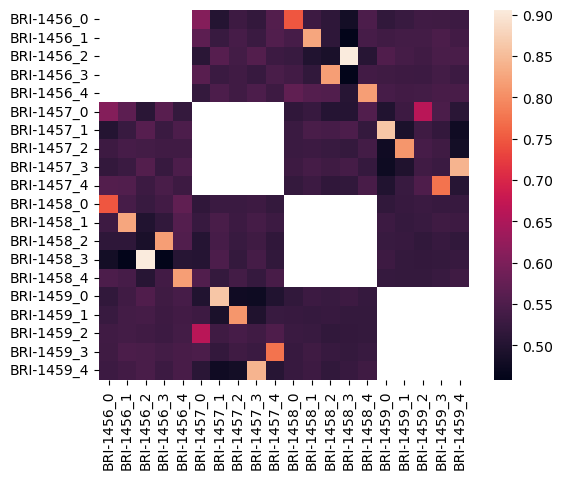

In [40]:
sns.heatmap(gt_ratio, xticklabels=sample_participants, yticklabels=sample_participants, square=True)

#### Check bulk RNA seq

In [65]:
import numpy as np
import vcfpy

In [59]:
filtered_vcfs_fp = os.path.join(INPUT_DIR, "bulk_vcfs/paired_star_freebayes_filtered")

In [57]:
sample_names = pd.DataFrame({"sample_name": """20220114_20L_LL9464_S22
20220114_30L_LL9464_S26
20220114_35L_LL9464_S29
20220114_L19_LL9464_S21
20220114_L22_LL9464_S23
20220114_L25_LL9464_S24
20220114_L27_LL9464_S25
20220114_L33_LL9464_S27
20220114_L34_LL9464_S28
20220114_L40_LL9464_S30
20220114_O19_LL9464_S1
20220114_O20_LL9464_S2
20220114_O22_LL9464_S3
20220114_O25_LL9464_S4
20220114_O27_LL9464_S5
20220114_O30_LL9464_S6
20220114_O33_LL9464_S7
20220114_O34_LL9464_S8
20220114_O35_LL9464_S9
20220114_O40_LL9464_S10
20220114_20S_LL9464_S12
20220114_S19_LL9464_S11
20220114_S22_LL9464_S13
20220114_S25_LL9464_S14
20220114_S27_LL9464_S15
20220114_S30_LL9464_S16
20220114_S33_LL9464_S17
20220114_S34_LL9464_S18
20220114_S35_LL9464_S19
20220114_S40_LL9464_S20""".split("\n")})

sample_names["participant"] = sample_names["sample_name"].str.extract("_(?:[a-zA-Z])?(\\d{2})(?:[a-zA-Z])?_")
tissue = sample_names["sample_name"].str.extract("_([A-Za-z])\\d{2}|\\d{2}([A-Za-z])_")
tissue.loc[tissue[0].isna(), 0] = tissue.loc[tissue[0].isna(), 1]
sample_names["tissue"] = tissue[0]
sample_names = sample_names.sort_values(["tissue", "participant"])
sample_names

,sample_name,participant,tissue
3,20220114_L19_LL9464_S21,19,L
0,20220114_20L_LL9464_S22,20,L
4,20220114_L22_LL9464_S23,22,L
5,20220114_L25_LL9464_S24,25,L
6,20220114_L27_LL9464_S25,27,L
1,20220114_30L_LL9464_S26,30,L
7,20220114_L33_LL9464_S27,33,L
8,20220114_L34_LL9464_S28,34,L
2,20220114_35L_LL9464_S29,35,L
9,20220114_L40_LL9464_S30,40,L


In [67]:
n = sample_names.shape[0]

bulk_gt_intersect = np.zeros((n, n), dtype=int)
bulk_gt_common = np.zeros((n, n), dtype=int)


for i, sample_name1 in enumerate(sample_names["sample_name"]):

    for j in range(i):
        
        sample_name2 = sample_names["sample_name"].iloc[j]
        
        vcf1_fp = os.path.join(filtered_vcfs_fp, f"{sample_name1}.{sample_name2}.vcf.gz")
        reader1 = vcfpy.Reader.from_path(vcf1_fp)

        vcf2_fp = os.path.join(filtered_vcfs_fp, f"{sample_name2}.{sample_name1}.vcf.gz")
        reader2 = vcfpy.Reader.from_path(vcf2_fp)
        
        for record1, record2 in zip(reader1, reader2):
            
            if record1.REF != record2.REF:
                continue
                
            assert record1.CHROM == record2.CHROM, f"{record1.CHROM} != {record2.CHROM}"
            assert record1.POS == record2.POS, f"{record1.POS} != {record2.POS}"
            assert len(record1.calls) == 1, f"{len(record1.calls)} != 1"
            assert len(record2.calls) == 1, f"{len(record2.calls)} != 1"

            alts1 = [alt.value for alt in record1.ALT]
            nucs1 = [record1.REF, ] + alts1
            alts2 = [alt.value for alt in record2.ALT]
            nucs2 = [record2.REF, ] + alts2

            call1 = record1.calls[0]
            call2 = record2.calls[0]
            
            gt1 = call1.data.get('GT') or './.'
                
            if gt1 == './.':
                continue
            
            gt2 = call2.data.get('GT') or './.'
                    
            if gt2 == './.':
                continue
            
            gt1_alts = [int(m) for m in gt1.split("/")]
            gt1_nucs = tuple(sorted([nucs1[m] for m in gt1_alts]))        
                        
            gt2_alts = [int(m) for m in gt2.split("/")]
            gt2_nucs = tuple(sorted([nucs2[m] for m in gt2_alts]))

            bulk_gt_common[i, j] += 1
            bulk_gt_common[j, i] += 1

            if gt1_nucs == gt2_nucs:
                bulk_gt_intersect[i, j] += 1
                bulk_gt_intersect[j, i] += 1
            

In [70]:
bulk_gt_ratio = bulk_gt_intersect / bulk_gt_common

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15918/2600934188.py:1: RuntimeWarning: invalid value encountered in divide
  bulk_gt_ratio = bulk_gt_intersect / bulk_gt_common


In [71]:
sample_names["short_name"] = sample_names["tissue"] + "_" + sample_names["participant"]

<Axes: >

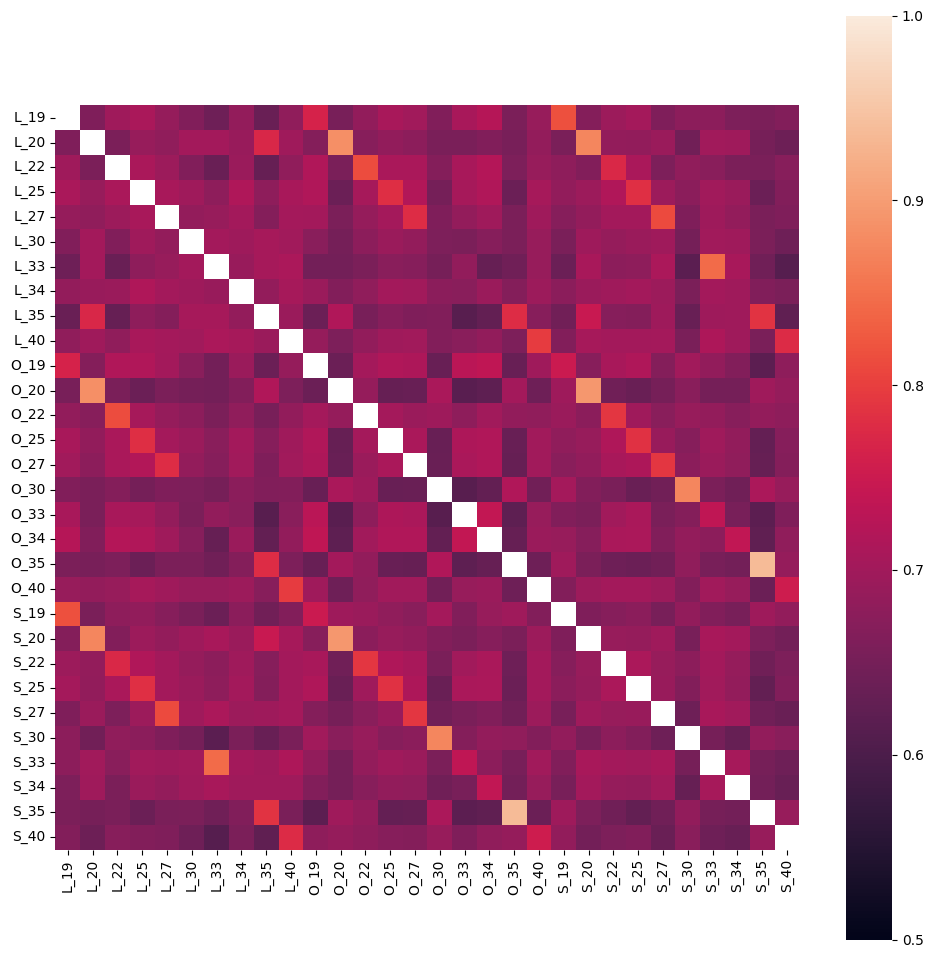

In [74]:
fig, ax = plt.subplots(figsize=(12, 12))

sns.heatmap(
    bulk_gt_ratio, xticklabels=sample_names["short_name"], yticklabels=sample_names["short_name"], square=True, ax=ax, vmin=0.5, vmax=1
)

In [76]:
bulk_gt_intersect_df = pd.DataFrame(bulk_gt_intersect, columns=sample_names["short_name"], index=sample_names["short_name"])
bulk_gt_intersect_df.to_csv(os.path.join(INPUT_DIR, "bulk_vcfs", "bulk_gt_intersect.csv"))

In [77]:
bulk_gt_common_df = pd.DataFrame(bulk_gt_common, columns=sample_names["short_name"], index=sample_names["short_name"])
bulk_gt_common_df.to_csv(os.path.join(INPUT_DIR, "bulk_vcfs", "bulk_gt_common.csv"))

### Intersecting vcfs

In [6]:
INPUT_DIR = "/Users/willtrim/Documents/projs/obesity_scRNAseq/inputs/demultiplex/sample_intercept_attempt"

In [1]:
import glob

import vcfpy

import numpy as np

In [30]:
matching_samples = {
    "BRI-1456": {
        "BRI-1458": {
            0: 0,
            1: 1,
            2: 3,
            3: 2,
            4: 4,
        }
    },
    "BRI-1457": {
        "BRI-1459": {
            0: 2,
            1: 0,
            2: 1,
            3: 4,
            4: 3,
        },
    },
}

In [33]:
for lib_name1, other_libs in matching_samples.items():

    lib1_clusters_vcf_fp = os.path.join(INPUT_DIR, f"{lib_name1}.cluster_genotypes.vcf")

    
    for lib_name2, lib_matching_samples in other_libs.items():
        
        records_in = 0
        records_out = 0
        records_redacted = 0
        
        lib2_clusters_vcf_fp = os.path.join(INPUT_DIR, f"{lib_name2}.cluster_genotypes.vcf")
        
        reader2 = vcfpy.Reader.from_path(lib2_clusters_vcf_fp)
        reader1 = vcfpy.Reader.from_path(lib1_clusters_vcf_fp)

        output_vcf_path = os.path.join(INPUT_DIR, f"{lib_name1}.{lib_name2}.cluster_genotypes.vcf")
        writer = vcfpy.Writer.from_path(output_vcf_path, reader1.header)

        for record1, record2 in zip(reader1, reader2):
            assert record1.CHROM == record2.CHROM, f"{record1.CHROM} != {record2.CHROM}"
            assert record1.POS == record2.POS, f"{record1.POS} != {record2.POS}"
            # assert record1.REF == record2.REF, f"{record1.REF} != {record2.REF}"

            record1_gts = {}
            record2_gts = {}

            for record, record_gts in zip([record1, record2], [record1_gts, record2_gts]):
                
                alts = [alt.value for alt in record.ALT]
                nucs = [record.REF, ] + alts
                
                for k, call in enumerate(record.calls):
                    
                    gt = call.data.get('GT') or './.'
                    
                    if gt == './.':
                        record_gts[k] = "./."
    
                    else:
                        gt_alts = [int(m) for m in gt.split("/")]
                        gt_nucs = tuple(sorted([nucs[m] for m in gt_alts]))
                        record_gts[k] = gt_nucs
                        
            empty_num = 0
            redacted = False
            
            for sample_i1, sample_i2 in lib_matching_samples.items():
                gt1 = record1_gts[sample_i1]
                gt2 = record2_gts[sample_i2]

                if gt1 != gt2:
                    record1.calls[sample_i1].data["GT"] = "./."
                    empty_num += 1
                    redacted = True

                elif gt1 == "./.":
                    empty_num += 1

            records_in += 1
            if redacted:
                records_redacted += 1
                
            
            if empty_num != len(lib_matching_samples):
                writer.write_record(record1)
                records_out += 1

        reader1.close()
        reader2.close()
        writer.close()

        print(f"{lib_name1}/{lib_name2} in/out/redacted:\t{records_in}/{records_out}/{records_redacted}")

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT T not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT E not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GO not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/header.py:471: FieldInfoNotFound: FORMAT GN not found using String/'.' instead
  warnings.warn(
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/vcfpy/parser.py:515: UnknownFilter: Filter not found in header: BACKGROUND; problem in FILTER column
  warnings.warn(


BRI-1456/BRI-1458 in/out/redacted:	27128/26898/20012
BRI-1457/BRI-1459 in/out/redacted:	65119/64358/56158
